> **Note:** This notebook was originally developed and run in Google Colab as part of my BSc thesis (Software Engineering, Canadian Institute of Technology).
> Cells using `google.colab.files.upload()` were used to load CSVs interactively in Colab — if running locally, replace these with a direct `pd.read_csv('path/to/file.csv')` pointing at the dataset described in the main README.
>
> **Dataset:** [Diabetes 130-US hospitals for years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (UCI Machine Learning Repository, public domain).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder, OneHotEncoder, MinMaxScaler
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# number of rows and columns
df.shape

(101766, 50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df['encounter_id'].nunique()

101766

In [ ]:
df['patient_nbr'].nunique()

71518

In [ ]:
df.duplicated(subset='patient_nbr').sum()

30248

In [ ]:
df.duplicated(subset=['patient_nbr', 'encounter_id']).sum()


0

In [ ]:
unique_patients_before = df['patient_nbr'].nunique()
print(f"Unique patients before: {unique_patients_before}")

Unique patients before: 71518


In [ ]:
# Sort by patient number and encounter ID to ensure that the first encounter comes first
df_sorted = df.sort_values(by=['patient_nbr', 'encounter_id'])

# Drop duplicate rows, keeping only the first encounter for each patient
df_first_encounter = df_sorted.drop_duplicates(subset='patient_nbr', keep='first')


In [ ]:
unique_patients_after = df_first_encounter['patient_nbr'].nunique()
print(f"Unique patients after: {unique_patients_after}")

Unique patients after: 71518


In [ ]:
# Check for duplicate patient numbers
duplicate_patients = df_first_encounter.duplicated(subset='patient_nbr').sum()

print(f"Number of duplicate patients after filtering: {duplicate_patients}")


Number of duplicate patients after filtering: 0


encounter_id and patient_nbr are just identifiers and not useful variables. will be dropped :

In [ ]:
df= df.drop(columns=['encounter_id', 'patient_nbr'])

In [ ]:
for c in df.columns:
    # Get unique values
    unique_vals = df[c].unique()

    # Print the values or number of unique values based on the count
    if len(unique_vals) < 30:
        print(f"{c}: {unique_vals}")
    else:
        print(f"{c}: {len(unique_vals)} unique values")

race: ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']
gender: ['Female' 'Male' 'Unknown/Invalid']
age: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
weight: ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
admission_type_id: [6 1 2 3 4 5 8 7]
discharge_disposition_id: [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
admission_source_id: [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
time_in_hospital: [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
payer_code: ['?' 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
medical_specialty: 73 unique values
num_lab_procedures: 118 unique values
num_procedures: [0 5 1 6 2 3 4]
num_medications: 75 unique values
number_outpatient: 39 unique values
number_emergency: 33 unique values
number_inpatient: [ 0  1  2  3  6  5  4  7  8  9 15 10 11 14 12 13 17 16 2

a mix of categorical and numerical data.
- '?' denotes missing values
-examide and citoglipton only have 1 value (not prescribed to any patient), will not be used

Numerical Features ( come back to them, add more information):

In [ ]:

cols_num = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient','number_diagnoses']

In [ ]:
missing_values = df[cols_num].apply(lambda x: (x == '?').sum())
print(missing_values)

time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
dtype: int64


In [ ]:
cols_cat = ['race', 'gender', 'age', 'weight', 'max_glu_serum', 'A1Cresult', 'admission_type_id', 'discharge_disposition_id',
 'admission_source_id', 'payer_code','medical_specialty', 'diag_1', 'diag_2','diag_3',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed']

missing_v = df[cols_cat].apply(lambda x: (x == '?').sum())
print(missing_v)

race                         2273
gender                          0
age                             0
weight                      98569
max_glu_serum                   0
A1Cresult                       0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
payer_code                  40256
medical_specialty           49949
diag_1                         21
diag_2                        358
diag_3                       1423
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
tolazamide                      0
insulin       

In [ ]:
df.readmitted.value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
# apply binary encoding
df['readmitted'] = (df['readmitted'] == '<30').astype(int)


In [ ]:
def calc_prevalence(y_actual):
    return (sum(y_actual)/len(y_actual))
print('Prevalence:%.3f'%calc_prevalence(df['readmitted'].values))

Prevalence:0.112


comments about the prevalance and population

In [ ]:
# a copy of the original DataFrame for preprocessing
df_copy = df.copy(deep=True)

Preprocessing

Will split the dataset into 3 parts: Training samples, Validation samples and Test samples. To measure how well the model would do on unseen data. Split the data in the beginning to avoid data leakage.
Split into 70% train, 15% validation, 15% test


In [ ]:
 #shuffle the samples
df = df.sample(n = len(df), random_state = 123)
df= df.reset_index(drop = True)

In [ ]:
#split into validation/test sets
df_valid_test = df.sample(frac=0.30, random_state=123)
print('Split size: %.3f'%(len(df_valid_test)/len(df)))

Split size: 0.300


In [ ]:
#split into test and validation
df_test = df_valid_test.sample(frac=0.5, random_state=123)
df_valid = df_valid_test.drop(df_test.index)


In [ ]:
#assign the remaining data to training set
df_train = df.drop(df_valid_test.index)

In [ ]:
# Print prevalence and count for each dataset with a different format
print(f'Test set - Count: {len(df_test):,}, Prevalence: {calc_prevalence(df_test.readmitted.values):.3f}')
print(f'Validation set - Count: {len(df_valid):,}, Prevalence: {calc_prevalence(df_valid.readmitted.values):.3f}')
print(f'Training set - Count: {len(df_train):,}, Prevalence: {calc_prevalence(df_train.readmitted.values):.3f}')


Test set - Count: 15,265, Prevalence: 0.117
Validation set - Count: 15,265, Prevalence: 0.109
Training set - Count: 71,236, Prevalence: 0.111


In [ ]:
df_test0 = df_test.copy(deep=True)
df_valid0 = df_valid.copy(deep=True)
df_train0 = df_train.copy(deep=True)

In [ ]:
df_train.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,OUTPUT_LABEL
0,Caucasian,Male,[60-70),?,1,1,7,3,HM,?,49,6,27,0,0,2,996,250.11,250.6,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
1,Caucasian,Female,[90-100),?,3,3,1,5,MC,?,57,0,21,0,0,1,682,274,250,9,NaN,NaN,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0
3,Caucasian,Male,[50-60),?,6,8,17,9,?,InternalMedicine,61,6,27,1,2,0,250.8,730,707,9,NaN,>8,Steady,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Female,[50-60),?,3,1,1,7,MC,Psychology,23,0,13,0,1,2,296,453,295,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,NO,0
5,Caucasian,Male,[50-60),?,2,18,1,9,?,?,65,6,40,0,0,0,410,272,401,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0


race - categorical feature

race
Caucasian          53380
AfricanAmerican    13426
?                   1558
Hispanic            1388
Other               1056
Asian                428
Name: count, dtype: int64


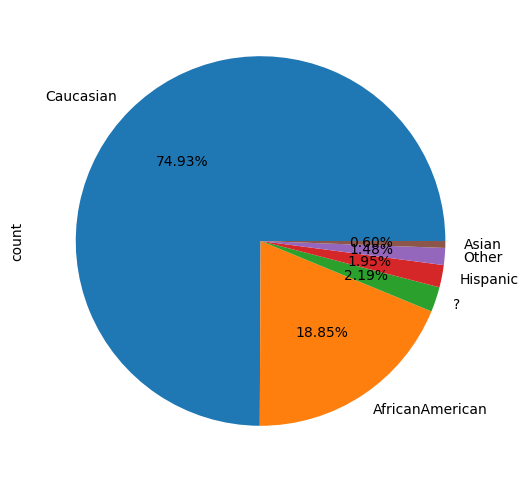

In [ ]:
print(df_train['race'].value_counts())
df_train['race'].value_counts().plot(kind='pie',autopct='%.2f%%',figsize=(16,6))
plt.show()

In [ ]:
df_train['race'] = df_train['race'].replace('?',np.nan)
df_train['race'].isna().sum()*100/df.shape[0]

1.530963190063479

In [ ]:
#adding another categorical type or the missing values
df_train['race'] = df_train['race'].fillna('UNK')

one-hot encoding technique
drop_first parameter in the pd.get_dummies function is used to avoid multicollinearity

In [ ]:
# One-hot encoding
df_train = pd.get_dummies(df_train, columns=['race'], drop_first=True)


In [ ]:
for col in df_train.columns:
    if 'race' in col:
        df_train[col] = df_train[col].astype(int)

In [ ]:
df_train.head()

,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,OUTPUT_LABEL,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK
0,Male,[60-70),?,1,1,7,3,HM,?,49,6,27,0,0,2,996,250.11,250.6,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,0,1,0,0,0
1,Female,[90-100),?,3,3,1,5,MC,?,57,0,21,0,0,1,682,274,250,9,NaN,NaN,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0,0,1,0,0,0
3,Male,[50-60),?,6,8,17,9,?,InternalMedicine,61,6,27,1,2,0,250.8,730,707,9,NaN,>8,Steady,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0,0,1,0,0,0
4,Female,[50-60),?,3,1,1,7,MC,Psychology,23,0,13,0,1,2,296,453,295,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,NO,0,0,1,0,0,0
5,Male,[50-60),?,2,18,1,9,?,?,65,6,40,0,0,0,410,272,401,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0,1,0,0,0


gender - categorical feature

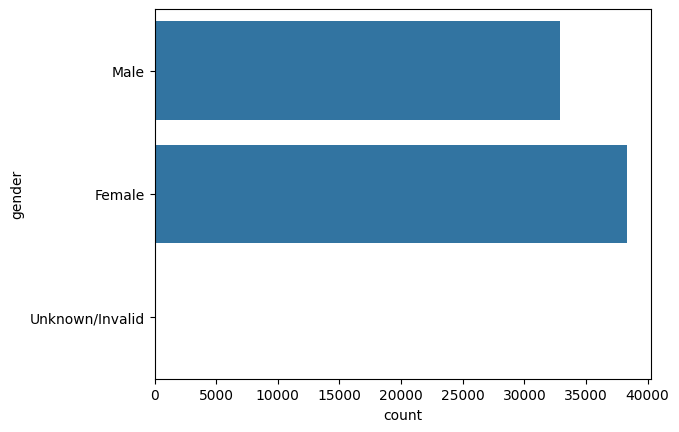

gender
Female             38319
Male               32916
Unknown/Invalid        1
Name: count, dtype: int64


In [ ]:
sns.countplot(df_train.gender)
plt.show()
print(df_train.gender.value_counts())

3 categories female, male, unknown/invalid. unknown/invalid category only has 1 value hence they can be dropped.

In [ ]:
df_train = df_train[df_train['gender'] != 'Unknown/Invalid']

# verify the unique values in the 'gender' column
print(df_train['gender'].unique())

['Male' 'Female']


In [ ]:
#encoding gender
df_train['gender'] = df_train['gender'].replace({'Female' : 0, 'Male' : 1})
print(df_train['gender'].unique())

[1 0]


Age- categorical feature, in 10 age ranges like ( age: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)'])

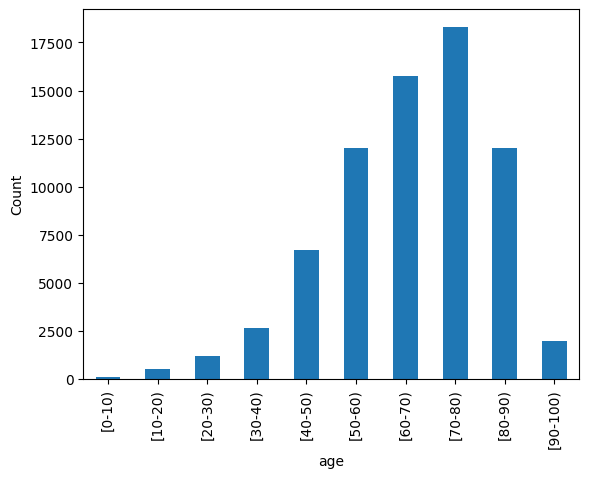

In [ ]:
# checking 'age' feature
df_train.groupby('age').size().plot(kind='bar')
plt.ylabel('Count')
plt.show()

map categorical bin labels to numerical values


In [ ]:
df_train['age'] = df_train['age'].map({'[0-10)': 0,
                                     '[10-20)': 10,
                                      '[20-30)': 20,
                                      '[30-40)': 30,
                                      '[40-50)': 40,
                                      '[50-60)': 50,
                                      '[60-70)': 60,
                                      '[70-80)': 70,
                                      '[80-90)': 80,
                                     '[90-100)': 90})
df_train['age'].value_counts()

,count
age,
70,18304
60,15774
50,12023
80,12014
40,6732
30,2626
90,1980
20,1171
10,495


weight

In [ ]:
df_train.weight.value_counts(1)*100

,proportion
weight,
?,96.875132
[75-100),1.350460
[50-75),0.824033
[100-125),0.609251
[125-150),0.150207
[25-50),0.089843
[0-25),0.054748
[150-175),0.035095
[175-200),0.008423


In [ ]:
df_train['weight'] = df_train['weight'].replace('?',np.nan)

Deciding if weight is important or not

In [ ]:
df_train.groupby('age')['weight'].apply(lambda x: x.isnull().mean())

,weight
age,
0,0.956897
10,0.969697
20,0.959863
30,0.978675
40,0.974153
50,0.971471
60,0.969443
70,0.963341
80,0.969036


Descriptive Statistics
Check if missing values in the feature correlate with other variables (  is not  missing more frequently for certain age groups, genders)

In [ ]:
import missingno as msno

<Axes: >

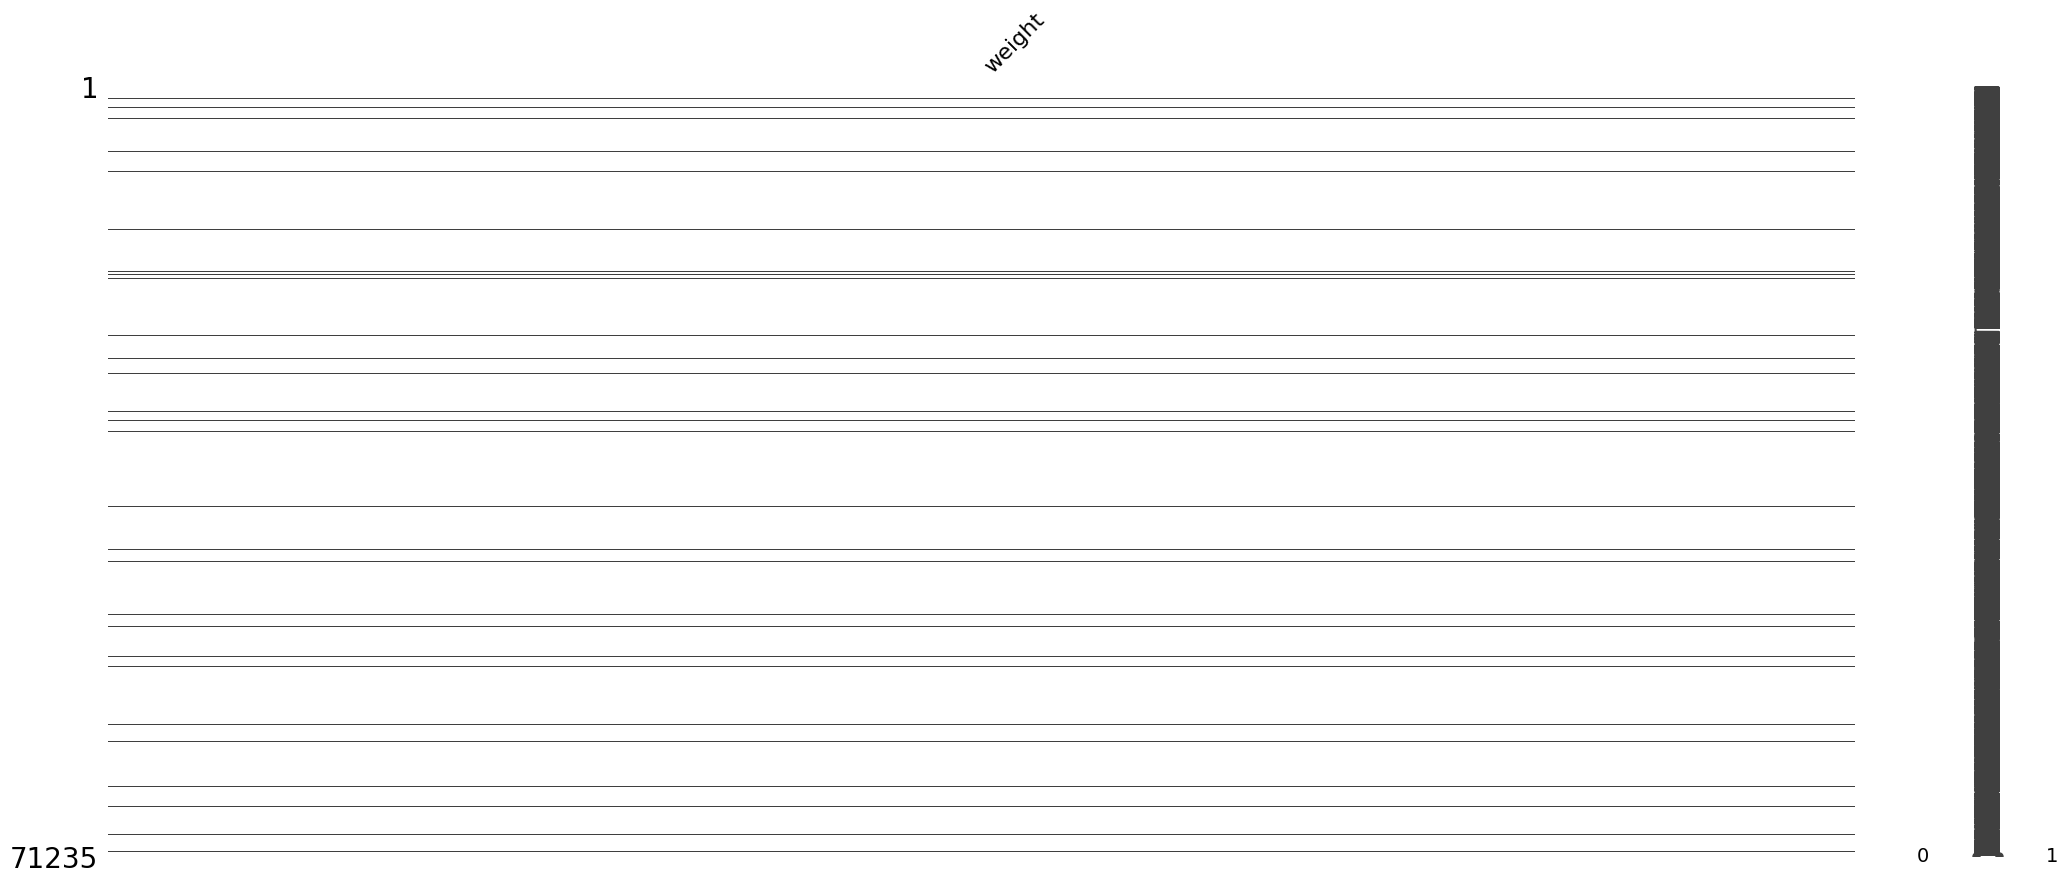

In [ ]:
df_train_weight = df_train[['weight']]

# Visualize missing data patterns for the 'weight' column
msno.matrix(df_train_weight)

The pattern of missing values appears random, without any obvious systematic pattern

In [ ]:
# Separate ages based on missingness in 'weight'
complete = df_train.loc[df_train['weight'].notnull(), 'age']
missing = df_train.loc[df_train['weight'].isnull(), 'age']

# Perform a t-test to compare means
t_stat, p_value = stats.ttest_ind(complete, missing, nan_policy='omit')

print(f'T-test statistic: {t_stat}')
print(f'P-value: {p_value}')

T-test statistic: 3.0453822670737
P-value: 0.002324696072872881


In [ ]:
#drop weight column
df_train.drop(['weight'],axis=1,inplace=True)

In [ ]:
df_train.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK
0,1,60,1,1,7,3,HM,?,49,6,27,0,0,2,996,250.11,250.6,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,0,1,0,0,0
1,0,90,3,3,1,5,MC,?,57,0,21,0,0,1,682,274,250,9,NaN,NaN,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,0,0,1,0,0,0
3,1,50,6,8,17,9,?,InternalMedicine,61,6,27,1,2,0,250.8,730,707,9,NaN,>8,Steady,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,0,0,1,0,0,0
4,0,50,3,1,1,7,MC,Psychology,23,0,13,0,1,2,296,453,295,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,0,0,1,0,0,0
5,1,50,2,18,1,9,?,?,65,6,40,0,0,0,410,272,401,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,1,0,0,0


admission_type_id - numerical here, but are IDs (see IDs_mapping). Each Id corresponds to 8 distinct values. 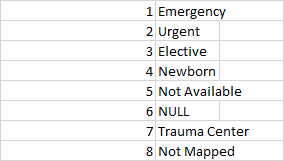

Grouping the admission_type id into less categories, this can simplify the data and capture meaningful patterns without losing too much detail.

Emergency/Urgent/Trauma Center → Emergency
These categories often involve urgent or critical situations.

Not Available/NULL/Not Mapped → Not Available
These categories indicate missing or unspecified information.

Elective → Elective

Newborn → Newborn

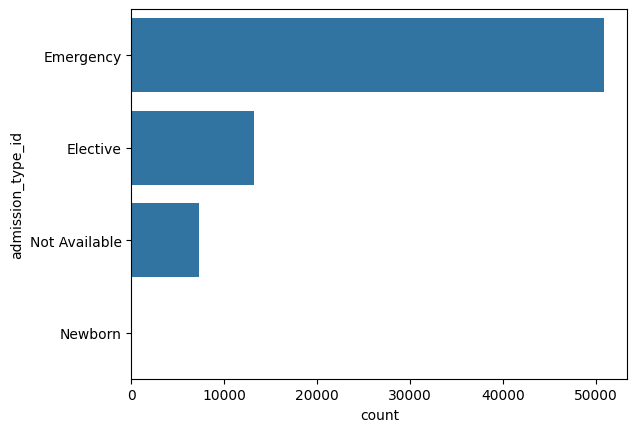

In [ ]:
df_train['admission_type_id']=df_train['admission_type_id'].replace({1:'Emergency',2:'Emergency',7:'Emergency',
                                 5:'Not Available', 6:'Not Available', 8:'Not Available',
                                 3:'Elective',4:'Newborn'})

sns.countplot(df_train['admission_type_id'])
plt.show()

In [ ]:
# show counts of each category for 'admission_type_id'
admission_type_counts = df_train['admission_type_id'].value_counts()

print(admission_type_counts)

admission_type_id
Emergency        50818
Elective         13179
Not Available     7231
Newborn              7
Name: count, dtype: int64


Checking the Newborn values

In [ ]:
df_train[df_train['admission_type_id']== 'Newborn'][['gender','age','admission_type_id']]

,gender,age,admission_type_id
29788,1,60,Newborn
38586,1,60,Newborn
51075,1,80,Newborn
53703,1,40,Newborn
71432,0,60,Newborn
90245,1,50,Newborn
93942,0,0,Newborn


 The 'Newborn' category posibibly introduces noise due to inconsistent and improbable age values. Decide to drop this category.

In [ ]:
#drop 'Newborn' values
df_train=df_train[df_train['admission_type_id']!='Newborn']

In [ ]:
category_to_id = {
    'Emergency': 1,
    'Not Available': 5,
    'Elective': 3,
}

# replace category labels with their corresponding numeric IDs
df_train['admission_type_id'] = df_train['admission_type_id'].map(category_to_id)

print(df_train['admission_type_id'].value_counts())

admission_type_id
1    50818
3    13179
5     7231
Name: count, dtype: int64


discharge_disposition_id
1	Discharged to home
2	Discharged/transferred to another short term hospital
3	Discharged/transferred to SNF
4	Discharged/transferred to ICF
5	Discharged/transferred to another type of inpatient care institution
6	Discharged/transferred to home with home health service
7	Left AMA
8	Discharged/transferred to home under care of Home IV provider
9	Admitted as an inpatient to this hospital
10	Neonate discharged to another hospital for neonatal aftercare
11	Expired
12	Still patient or expected to return for outpatient services
13	Hospice / home
14	Hospice / medical facility
15	Discharged/transferred within this institution to Medicare approved swing bed
16	Discharged/transferred/referred another institution for outpatient services
17	Discharged/transferred/referred to this institution for outpatient services
18	NULL
19	Expired at home. Medicaid only, hospice.
20	Expired in a medical facility. Medicaid only, hospice.
21	Expired, place unknown. Medicaid only, hospice.
22	Discharged/transferred to another rehab fac including rehab units of a hospital .
23	Discharged/transferred to a long term care hospital.
24	Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.

25	Not Mapped
26	Unknown/Invalid
30	Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere
27	Discharged/transferred to a federal health care facility.
28	Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital
29	Discharged/transferred to a Critical Access Hospital (CAH).



1,6,8 - Discharged to home

2,3,4,5,10,16,22,23,24,27,28,29,30- Transferred to Another Medical Facility

 7 - Left AMA (Against Medical Advice)

 9,12,15,17 - Still Patient/Referred

 11,19,20,21 - Expired

 13,14 - Hospice

 18,25,26 - Not Available

 10-Neonate discharged

In [ ]:
discharge = df_train['discharge_disposition_id'].value_counts()
print(discharge)

discharge_disposition_id
1     41995
3      9896
6      9072
18     2588
2      1481
22     1407
11     1141
5       812
25      703
4       565
7       432
23      288
13      277
14      265
28       99
8        75
15       47
24       35
9        16
17        9
16        8
19        5
27        5
10        5
20        1
12        1
Name: count, dtype: int64


In [ ]:
df_train['discharge_disposition_id'] = df_train['discharge_disposition_id'].replace({
    1: 'Discharged to home',
    6: 'Discharged to home',
    8: 'Discharged to home',

    2: 'Transferred to Another Medical Facility',
    3: 'Transferred to Another Medical Facility',
    4: 'Transferred to Another Medical Facility',
    5: 'Transferred to Another Medical Facility',
    10: 'Neonate discharged',
    16: 'Transferred to Another Medical Facility',
    22: 'Transferred to Another Medical Facility',
    23: 'Transferred to Another Medical Facility',
    24: 'Transferred to Another Medical Facility',
    27: 'Transferred to Another Medical Facility',
    28: 'Transferred to Another Medical Facility',
    29: 'Transferred to Another Medical Facility',
    30: 'Transferred to Another Medical Facility',

    7: 'Left AMA (Against Medical Advice)',

    9: 'Still Patient/Referred',
    12: 'Still Patient/Referred',
    15: 'Still Patient/Referred',
    17: 'Still Patient/Referred',

    11: 'Expired',
    19: 'Expired',
    20: 'Expired',
    21: 'Expired',

    13: 'Hospice',
    14: 'Hospice',

    18: 'Not Available',
    25: 'Not Available',
    26: 'Not Available'
})

In [ ]:
df_train.discharge_disposition_id.value_counts()

,count
discharge_disposition_id,
Discharged to home,51142
Transferred to Another Medical Facility,14596
Not Available,3291
Expired,1147
Hospice,542
Left AMA (Against Medical Advice),432
Still Patient/Referred,73
Neonate discharged,5


Neonates who are discharged for specialized neonatal care typically have different follow-up and readmission patterns. (small number of cases also ,5)

Expired - These patients have passed away and will not be readmitted.

Hospice-  Patients receiving end-of-life care are typically not expected to return for curative treatments, so including them could introduce bias.

In [ ]:
df_train = df_train[df_train['discharge_disposition_id'] != 'Expired']
df_train = df_train[df_train['discharge_disposition_id'] != 'Neonate discharged']
df_train = df_train[df_train['discharge_disposition_id'] != 'Hospice']

In [ ]:

# Check the value counts to ensure the categories are correctly combined
print(df_train['discharge_disposition_id'].value_counts())

discharge_disposition_id
Discharged to home                         51142
Transferred to Another Medical Facility    14596
Not Available                               3291
Left AMA (Against Medical Advice)            432
Still Patient/Referred                        73
Name: count, dtype: int64


admission_source_id

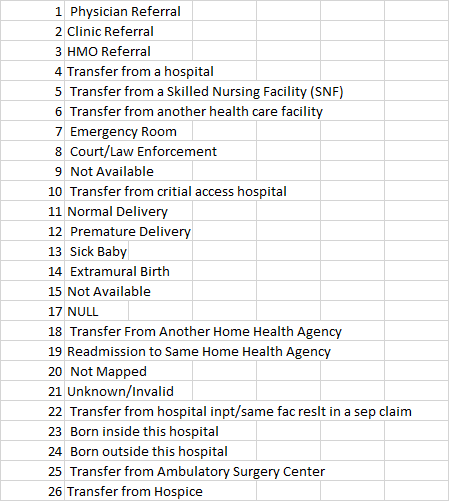

1,2,3 -Referral

4,5,6,10,18,22,25,26 - Transfer

7- Emergency Room

8- Court/Law Enforcement

9,15,17,20,21  - Not Available

11,12,13,14,23,24 - Delivery and Birth

19 - Readmission to Same Home Health Agency


In [ ]:
df_train['admission_source_id'] = df_train['admission_source_id'].replace({
    1: 'Referral',
    2: 'Referral',
    3: 'Referral',

    4: 'Transfer',
    5: 'Transfer',
    6: 'Transfer',
    10: 'Transfer',
    18: 'Transfer',
    22: 'Transfer',
    25: 'Transfer',
    26: 'Transfer',

    7: 'Emergency',
    8: 'Court/Law Enforcement',

    9: 'Not Available',
    15: 'Not Available',
    17: 'Not Available',
    20: 'Not Available',
    21: 'Not Available',

    11: 'Delivery and Birth',
    12: 'Delivery and Birth',
    13: 'Delivery and Birth',
    14: 'Delivery and Birth',
    23: 'Delivery and Birth',
    24: 'Delivery and Birth',

    19: 'Readmission to Same Home Health Agency'
})

19: 'Readmission to Same Home Health Agency' no values even in the whole dataset

In [ ]:
print(df_train['admission_source_id'].unique())

['Emergency' 'Referral' 'Not Available' 'Transfer' 'Court/Law Enforcement'
 'Delivery and Birth']


In [ ]:
df_train.admission_source_id.value_counts()

,count
admission_source_id,
Emergency,39126
Referral,21307
Not Available,4755
Transfer,4329
Court/Law Enforcement,13
Delivery and Birth,4


In [ ]:
df_train[df_train['admission_source_id']=='Delivery and Birth'][['gender','age','admission_source_id']]

,gender,age,admission_source_id
17875,0,20,Delivery and Birth
24606,0,70,Delivery and Birth
35854,0,70,Delivery and Birth
65980,1,70,Delivery and Birth


The values on columns 'age' and 'admission_source_id' give contradictory information so the Delivery and Birth category will be dropped

In [ ]:
df_train=df_train[df_train['admission_source_id']!='Delivery and Birth']

In [ ]:
print(df_train['admission_source_id'].unique())

['Emergency' 'Referral' 'Not Available' 'Transfer' 'Court/Law Enforcement']


Missing values

In [ ]:
df_train.admission_source_id.value_counts()

,count
admission_source_id,
Emergency,39126
Referral,21307
Not Available,4755
Transfer,4329
Court/Law Enforcement,13


In [ ]:
df_train.admission_type_id.value_counts()

,count
admission_type_id,
1,49448
3,13036
5,7046


identified missing values in the 'admission_source_id' column.
To fill these gaps, we used the 'admission_type_id' column as a reference,
assuming that 'Emergency' admissions should align with 'Emergency' sources,
'Elective' admissions with 'Referral' sources, and so on.


In [ ]:
def impute_source(row):
    if row['admission_source_id'] == 'Not Available':
        if row['admission_type_id'] == 1:  # Emergency
            return 'Emergency'
        elif row['admission_type_id'] == 3:  # Elective
            return 'Referral'
    return row['admission_source_id']

# Apply the function to fill missing values
df_train['admission_source_id'] = df_train.apply(impute_source, axis=1)

# Check the results
print(df_train['admission_source_id'].value_counts())


admission_source_id
Emergency                39848
Referral                 21350
Transfer                  4329
Not Available             3990
Court/Law Enforcement       13
Name: count, dtype: int64


Time in hospital Number of days between admission and discharge

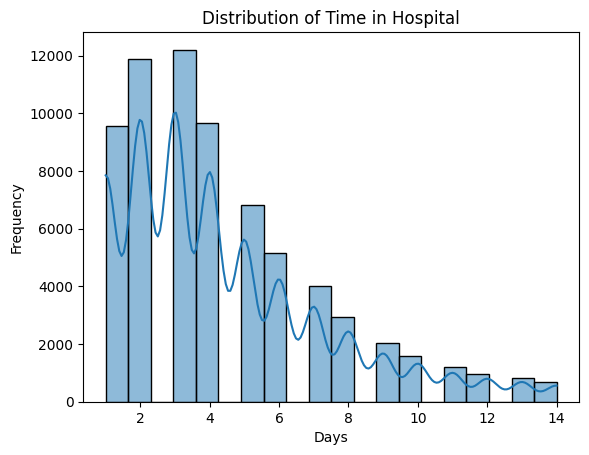

In [ ]:
sns.histplot(df_train['time_in_hospital'], bins=20, kde=True)
plt.title('Distribution of Time in Hospital')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

payer_code - Payer code refers to a unique alphanumeric code assigned to healthcare payers1. It is used for identification and billing purposes.

In [ ]:
df_train.payer_code.value_counts(1)*100

,proportion
payer_code,
?,39.565655
MC,31.584927
HM,6.273551
SP,4.948943
BC,4.566374
MD,3.480512
UN,2.486696
CP,2.485258
CM,1.931540


Dropping payer_code because of a high missing values, to simplify the model and reduce complexity.

In [ ]:
df_train.drop(columns=['payer_code'], axis=1, inplace=True)

medical_specialty

In [ ]:
df_train.medical_specialty.nunique()

68

In [ ]:
df_train.medical_specialty.value_counts(1)*100

,proportion
medical_specialty,
?,48.963038
InternalMedicine,14.366461
Emergency/Trauma,7.391054
Family/GeneralPractice,7.278872
Cardiology,5.284050
Surgery-General,3.092190
Nephrology,1.553286
Orthopedics,1.410902
Orthopedics-Reconstructive,1.248382


Dropping medical specialty beacuse 48.9 % of its values are missing



In [ ]:
df_train.drop(['medical_specialty'],axis=1,inplace=True)

num_procedures, num_lab_procedures, num_medications, number_outpatient, number_emergency, number_inpatient - are numerical features.

In [ ]:
df_train.num_procedures.value_counts()

,count
num_procedures,
0,31899
1,14226
2,8619
3,6470
6,3360
4,2842
5,2114


In [ ]:
print("Min value:", df_train['num_lab_procedures'].min())
print("Max value:", df_train['num_lab_procedures'].max())

print(df_train['num_lab_procedures'].describe())



Min value: 1
Max value: 132
count    69530.000000
mean        42.915864
std         19.574429
min          1.000000
25%         31.000000
50%         44.000000
75%         57.000000
max        132.000000
Name: num_lab_procedures, dtype: float64


In [ ]:
print("Min value:", df_train['num_medications'].min())
print("Max value:", df_train['num_medications'].max())

Min value: 1
Max value: 81


diag_1 -

diag_2 -

diag_3 -

In [ ]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']

missing = df_train[diag_cols].apply(lambda x: (x == '?').sum())
print(missing)

diag_1     13
diag_2    258
diag_3    981
dtype: int64


In [ ]:
df_train = df_train.reset_index(drop = True )

In [ ]:
unique_diag1 = df_train['diag_1'].unique()
unique_diag2 = df_train['diag_2'].unique()
unique_diag3 = df_train['diag_3'].unique()

print("Unique values in diag_1:", unique_diag1)
print("Unique values in diag_2:", unique_diag2)
print("Unique values in diag_3:", unique_diag3)

Unique values in diag_1: ['996' '682' '250.8' '296' '410' '433' '511' '426' '458' '780' '530' '414'
 '8' '428' '427' '434' '38' '592' '781' '562' '730' '786' '584' '599'
 '276' '604' '491' '535' '275' '250.03' '823' '250.13' 'V57' '253' '278'
 '820' '486' '250.7' '171' '435' '70' '453' '518' '620' '250.93' '558'
 '280' '250.11' '560' '532' '454' '577' '346' '812' 'V55' '805' '403'
 '578' '250.6' '424' '648' '821' '402' '437' '661' '415' '277' '493' '813'
 '596' '784' '250.2' '726' '287' '715' '211' '311' '9' '250.02' '574'
 '722' '997' '53' '621' '250.22' '440' '507' '557' '155' '285' '290' '540'
 '441' '431' '822' '112' '250.92' '482' '724' '386' '292' '274' '185'
 '572' '992' '789' '571' '519' '404' '481' '531' '250.12' '187' '567'
 '250.42' '729' '342' '204' '411' '154' '552' '250.82' '349' '998' '379'
 '861' '959' '808' '593' '235' '250' '288' '333' '197' '79' '575' '801'
 '686' '162' '401' '218' '425' '284' '569' '153' '787' '352' '310' '444'
 '238' '348' '295' '595' '654' '252' '

In [ ]:
diag_columns = ['diag_1', 'diag_2', 'diag_3']

In [ ]:
df_train.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,OUTPUT_LABEL,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK
0,1,60,1,Discharged to home,Emergency,3,49,6,27,0,0,2,996,250.11,250.6,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,0,1,0,0,0
1,0,90,3,Transferred to Another Medical Facility,Referral,5,57,0,21,0,0,1,682,274,250,9,NaN,NaN,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0,0,1,0,0,0
3,1,50,5,Discharged to home,Not Available,9,61,6,27,1,2,0,250.8,730,707,9,NaN,>8,Steady,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO,0,0,1,0,0,0
4,0,50,3,Discharged to home,Referral,7,23,0,13,0,1,2,296,453,295,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,NO,0,0,1,0,0,0
5,1,50,1,Not Available,Referral,9,65,6,40,0,0,0,410,272,401,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0,1,0,0,0


-1 - '?' values (missing)

0 - V01-V91  Supplementary Classification Of Factors Influencing Health Status
And Contact With Health Services

0 - E000-E999  Supplementary Classification Of External Causes Of Injury And Poisoning

1 - 1-139  Infectious And Parasitic Diseases
2 - 140-239  Neoplasms
3 - 240-279  Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders

4 - 280-289  Diseases Of The Blood And Blood-Forming Organs

5 - 290-319  Mental Disorders

6 - 320-389  Diseases Of The Nervous System And Sense Organs

7 - 390-459  Diseases Of The Circulatory System

8 - 460-519  Diseases Of The Respiratory System

9 - 520-579  Diseases Of The Digestive System

10 - 580-629  Diseases Of The Genitourinary System

11 - 630-679  Complications Of Pregnancy, Childbirth, And The Puerperium

12 - 680-709  Diseases Of The Skin And Subcutaneous Tissue

13 - 710-739  Diseases Of The Musculoskeletal System And Connective Tissue

14 - 740-759  Congenital Anomalies

15 - 760-779  Certain Conditions Originating In The Perinatal Period

16 - 780-799  Symptoms, Signs, And Ill-Defined Conditions

17 - 800-999  Injury And Poisoning

18 -  250 - Diabetes

Based on http://www.icd9data.com/2015/Volume1/default.htm

In [ ]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']
missing = df_train[diag_cols].apply(lambda x: (x == '?').sum())
print(missing)

diag_1     13
diag_2    258
diag_3    981
dtype: int64


In [ ]:
# replacing 'E' and 'V' codes with 0
df_train.loc[df_train['diag_1'].str.startswith('V', na=False), 'diag_1'] = 0
df_train.loc[df_train['diag_1'].str.startswith('E', na=False), 'diag_1'] = 0

# replacing '?' with -1
df_train['diag_1'] = df_train['diag_1'].replace('?', -1)

df_train['diag_1'] = pd.to_numeric(df_train['diag_1'], errors='coerce')

# classify Diagnoses by ICD-9
for index, row in df_train.iterrows():
    if pd.isna(row['diag_1']):
        df_train.loc[index, 'diag_1'] = -1
    elif row['diag_1'] == 250:
        df_train.loc[index, 'diag_1'] = 18
    elif 390 <= row['diag_1'] <= 459 or row['diag_1'] == 785:
        df_train.loc[index, 'diag_1'] = 7
    elif 460 <= row['diag_1'] <= 519 or row['diag_1'] ==786:
        df_train.loc[index, 'diag_1'] = 8
    elif 520 <= row['diag_1'] <= 579 or row['diag_1'] ==787:
        df_train.loc[index, 'diag_1'] = 9
    elif 580 <= row['diag_1'] <= 629 or row['diag_1'] ==788:
        df_train.loc[index, 'diag_1'] = 10
    elif 680 <= row['diag_1'] <= 709 or row['diag_1'] ==782:
        df_train.loc[index, 'diag_1'] = 12
    elif 1 <= row['diag_1'] <= 139:
        df_train.loc[index, 'diag_1'] = 1
    elif 140 <= row['diag_1'] <= 239:
        df_train.loc[index, 'diag_1'] = 2
    elif 240 <= row['diag_1'] <= 279:
        df_train.loc[index, 'diag_1'] = 3
    elif 280 <= row['diag_1'] <= 289:
        df_train.loc[index, 'diag_1'] = 4
    elif 290 <= row['diag_1'] <= 319:
        df_train.loc[index, 'diag_1'] = 5
    elif 320 <= row['diag_1'] <= 389:
        df_train.loc[index, 'diag_1'] = 6
    elif 630 <= row['diag_1'] <= 679:
        df_train.loc[index, 'diag_1'] = 11
    elif 710 <= row['diag_1'] <= 739:
        df_train.loc[index, 'diag_1'] = 13
    elif 740 <= row['diag_1'] <= 759:
        df_train.loc[index, 'diag_1'] = 14
    elif 760 <= row['diag_1'] <= 779:
        df_train.loc[index, 'diag_1'] = 15
    elif 780 <= row['diag_1'] <= 799:
        df_train.loc[index, 'diag_1'] = 16
    elif 800 <= row['diag_1'] <= 999:
        df_train.loc[index, 'diag_1'] = 17
    #
    elif row['diag_1'] == -1:
        df_train.loc[index, 'diag_1'] = -1
    else:
        df_train.loc[index, 'diag_1'] = 0



In [ ]:
unique_counts = df_train['diag_1'].value_counts()
print(unique_counts)

diag_1
 7.0     20735
 8.0      9825
 3.0      7791
 9.0      6503
 17.0     4819
 13.0     3507
 10.0     3426
 16.0     2171
 2.0      2162
 12.0     1790
 1.0      1775
 5.0      1586
 0.0      1148
 6.0       867
 4.0       759
 11.0      456
 18.0      159
 14.0       38
-1.0        13
Name: count, dtype: int64


In [ ]:
# replacing 'E' and 'V' codes with 0
df_train.loc[df_train['diag_2'].str.startswith('V', na=False), 'diag_2'] = 0
df_train.loc[df_train['diag_2'].str.startswith('E', na=False), 'diag_2'] = 0

# replacing '?' with -1
df_train['diag_2'] = df_train['diag_2'].replace('?', -1)

df_train['diag_2'] = pd.to_numeric(df_train['diag_2'], errors='coerce')

# classify Diagnoses by ICD-9
for index, row in df_train.iterrows():
    if pd.isna(row['diag_2']):
        df_train.loc[index, 'diag_2'] = -1
    elif row['diag_2'] == 250:
        df_train.loc[index, 'diag_2'] = 18
    elif 390 <= row['diag_2'] <= 459 or row['diag_2'] == 785:
        df_train.loc[index, 'diag_2'] = 7
    elif 460 <= row['diag_2'] <= 519 or row['diag_2'] ==786:
        df_train.loc[index, 'diag_2'] = 8
    elif 520 <= row['diag_2'] <= 579 or row['diag_2'] ==787:
        df_train.loc[index, 'diag_2'] = 9
    elif 580 <= row['diag_2'] <= 629 or row['diag_2'] ==788:
        df_train.loc[index, 'diag_2'] = 10
    elif 680 <= row['diag_2'] <= 709 or row['diag_2'] ==782:
        df_train.loc[index, 'diag_2'] = 12
    elif 1 <= row['diag_2'] <= 139:
        df_train.loc[index, 'diag_2'] = 1
    elif 140 <= row['diag_2'] <= 239:
        df_train.loc[index, 'diag_2'] = 2
    elif 240 <= row['diag_2'] <= 279:
        df_train.loc[index, 'diag_2'] = 3
    elif 280 <= row['diag_2'] <= 289:
        df_train.loc[index, 'diag_2'] = 4
    elif 290 <= row['diag_2'] <= 319:
        df_train.loc[index, 'diag_2'] = 5
    elif 320 <= row['diag_2'] <= 389:
        df_train.loc[index, 'diag_2'] = 6
    elif 630 <= row['diag_2'] <= 679:
        df_train.loc[index, 'diag_2'] = 11
    elif 710 <= row['diag_2'] <= 739:
        df_train.loc[index, 'diag_2'] = 13
    elif 740 <= row['diag_2'] <= 759:
        df_train.loc[index, 'diag_2'] = 14
    elif 760 <= row['diag_2'] <= 779:
        df_train.loc[index, 'diag_2'] = 15
    elif 780 <= row['diag_2'] <= 799:
        df_train.loc[index, 'diag_2'] = 16
    elif 800 <= row['diag_2'] <= 999:
        df_train.loc[index, 'diag_2'] = 17
    #
    elif row['diag_2'] == -1:
        df_train.loc[index, 'diag_2'] = -1
    else:
        df_train.loc[index, 'diag_2'] = 0


In [ ]:
unique_counts = df_train['diag_2'].value_counts()
print(unique_counts)

diag_2
 7.0     21739
 3.0     10354
 8.0      7288
 10.0     5656
 18.0     4261
 9.0      2841
 12.0     2512
 4.0      2070
 16.0     1916
 5.0      1862
 0.0      1734
 17.0     1678
 2.0      1621
 1.0      1279
 13.0     1236
 6.0       872
 11.0      283
-1.0       258
 14.0       70
Name: count, dtype: int64


In [ ]:
# replacing 'E' and 'V' codes with 0
df_train.loc[df_train['diag_3'].str.startswith('V', na=False), 'diag_3'] = 0
df_train.loc[df_train['diag_3'].str.startswith('E', na=False), 'diag_3'] = 0

# replacing '?' with -1
df_train['diag_3'] = df_train['diag_3'].replace('?', -1)

df_train['diag_3'] = pd.to_numeric(df_train['diag_3'], errors='coerce')

# classify Diagnoses by ICD-9
for index, row in df_train.iterrows():
    if pd.isna(row['diag_3']):
        df_train.loc[index, 'diag_3'] = -1
    elif row['diag_3'] == 250:
        df_train.loc[index, 'diag_3'] = 18
    elif 390 <= row['diag_3'] <= 459 or row['diag_3'] == 785:
        df_train.loc[index, 'diag_3'] = 7
    elif 460 <= row['diag_3'] <= 519 or row['diag_3'] ==786:
        df_train.loc[index, 'diag_3'] = 8
    elif 520 <= row['diag_3'] <= 579 or row['diag_3'] ==787:
        df_train.loc[index, 'diag_3'] = 9
    elif 580 <= row['diag_3'] <= 629 or row['diag_3'] ==788:
        df_train.loc[index, 'diag_3'] = 10
    elif 680 <= row['diag_3'] <= 709 or row['diag_3'] ==782:
        df_train.loc[index, 'diag_3'] = 12
    elif 1 <= row['diag_3'] <= 139:
        df_train.loc[index, 'diag_3'] = 1
    elif 140 <= row['diag_3'] <= 239:
        df_train.loc[index, 'diag_3'] = 2
    elif 240 <= row['diag_3'] <= 279:
        df_train.loc[index, 'diag_3'] = 3
    elif 280 <= row['diag_3'] <= 289:
        df_train.loc[index, 'diag_3'] = 4
    elif 290 <= row['diag_3'] <= 319:
        df_train.loc[index, 'diag_3'] = 5
    elif 320 <= row['diag_3'] <= 389:
        df_train.loc[index, 'diag_3'] = 6
    elif 630 <= row['diag_3'] <= 679:
        df_train.loc[index, 'diag_3'] = 11
    elif 710 <= row['diag_3'] <= 739:
        df_train.loc[index, 'diag_3'] = 13
    elif 740 <= row['diag_3'] <= 759:
        df_train.loc[index, 'diag_3'] = 14
    elif 760 <= row['diag_3'] <= 779:
        df_train.loc[index, 'diag_3'] = 15
    elif 780 <= row['diag_3'] <= 799:
        df_train.loc[index, 'diag_3'] = 16
    elif 800 <= row['diag_3'] <= 999:
        df_train.loc[index, 'diag_3'] = 17
    #
    elif row['diag_3'] == -1:
        df_train.loc[index, 'diag_3'] = -1
    else:
        df_train.loc[index, 'diag_3'] = 0


In [ ]:
unique_counts = df_train['diag_3'].value_counts()
print(unique_counts)

diag_3
 7.0     20702
 3.0     10094
 18.0     7953
 8.0      4961
 10.0     4527
 0.0      3515
 9.0      2695
 5.0      2185
 16.0     1879
 12.0     1774
 4.0      1707
 13.0     1318
 17.0     1311
 1.0      1294
 6.0      1216
 2.0      1145
-1.0       981
 11.0      210
 14.0       63
Name: count, dtype: int64


In [ ]:
import numpy as np

#  missingness indicators
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df_train[diag + '_missing'] = df_train[diag].replace(-1, np.nan).isna().astype(int)

other_columns = [
    'gender', 'age', 'time_in_hospital','num_lab_procedures',
    'num_procedures', 'num_medications'
]

# Check correlation of missingness indicators with other features
correlation_matrix = df_train[['diag_1_missing', 'diag_2_missing', 'diag_3_missing'] + other_columns].corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                    diag_1_missing  diag_2_missing  diag_3_missing    gender  \
diag_1_missing            1.000000       -0.000835       -0.001636  0.006320   
diag_2_missing           -0.000835        1.000000        0.381789  0.002293   
diag_3_missing           -0.001636        0.381789        1.000000  0.004376   
gender                    0.006320        0.002293        0.004376  1.000000   
age                       0.001317       -0.094278       -0.165221 -0.049818   
time_in_hospital         -0.000692       -0.030811       -0.067219 -0.028750   
num_lab_procedures       -0.000855       -0.003750       -0.033544 -0.001721   
num_procedures           -0.006410       -0.031092       -0.048787  0.063172   
num_medications          -0.001811       -0.056419       -0.096586 -0.019609   

                         age  time_in_hospital  num_lab_procedures  \
diag_1_missing      0.001317         -0.000692           -0.000855   
diag_2_missing     -0.094278         -0

In [ ]:
diag_columns = ['diag_1', 'diag_2', 'diag_3']

# a dictionary to store frequency distributions
frequency_distributions = {}

# calculate frequency distributions for each diag_ column
for diag in diag_columns:
    frequency = df_train[diag].value_counts(dropna=False)
    frequency_distributions[diag] = frequency


for diag, freq in frequency_distributions.items():
    print(f"Frequency distribution for {diag}:")
    print(freq)
    print()



Frequency distribution for diag_1:
diag_1
 7.0     20735
 8.0      9825
 3.0      7791
 9.0      6503
 17.0     4819
 13.0     3507
 10.0     3426
 16.0     2171
 2.0      2162
 12.0     1790
 1.0      1775
 5.0      1586
 0.0      1148
 6.0       867
 4.0       759
 11.0      456
 18.0      159
 14.0       38
-1.0        13
Name: count, dtype: int64

Frequency distribution for diag_2:
diag_2
 7.0     21739
 3.0     10354
 8.0      7288
 10.0     5656
 18.0     4261
 9.0      2841
 12.0     2512
 4.0      2070
 16.0     1916
 5.0      1862
 0.0      1734
 17.0     1678
 2.0      1621
 1.0      1279
 13.0     1236
 6.0       872
 11.0      283
-1.0       258
 14.0       70
Name: count, dtype: int64

Frequency distribution for diag_3:
diag_3
 7.0     20702
 3.0     10094
 18.0     7953
 8.0      4961
 10.0     4527
 0.0      3515
 9.0      2695
 5.0      2185
 16.0     1879
 12.0     1774
 4.0      1707
 13.0     1318
 17.0     1311
 1.0      1294
 6.0      1216
 2.0      1145
-1.0      

Mode Imputation for diag_1', 'diag_2', 'diag_3

In [ ]:
df_train[['diag_1', 'diag_2', 'diag_3']] = df_train[['diag_1', 'diag_2', 'diag_3']].replace(-1, np.nan)

In [ ]:
mode_value = 7

# Replace NaN values with the mode (7) in each diag_ column
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df_train[diag].fillna(mode_value, inplace=True)


In [ ]:
# check for remaining NaN values
nan_counts = df_train[['diag_1', 'diag_2', 'diag_3']].isna().sum()

# check for remaining -1 values
minus_one_counts = (df_train[['diag_1', 'diag_2', 'diag_3']] == -1).sum()

print("Remaining NaN values:")
print(nan_counts)
print("\nRemaining -1 values:")
print(minus_one_counts)


Remaining NaN values:
diag_1    0
diag_2    0
diag_3    0
dtype: int64

Remaining -1 values:
diag_1    0
diag_2    0
diag_3    0
dtype: int64


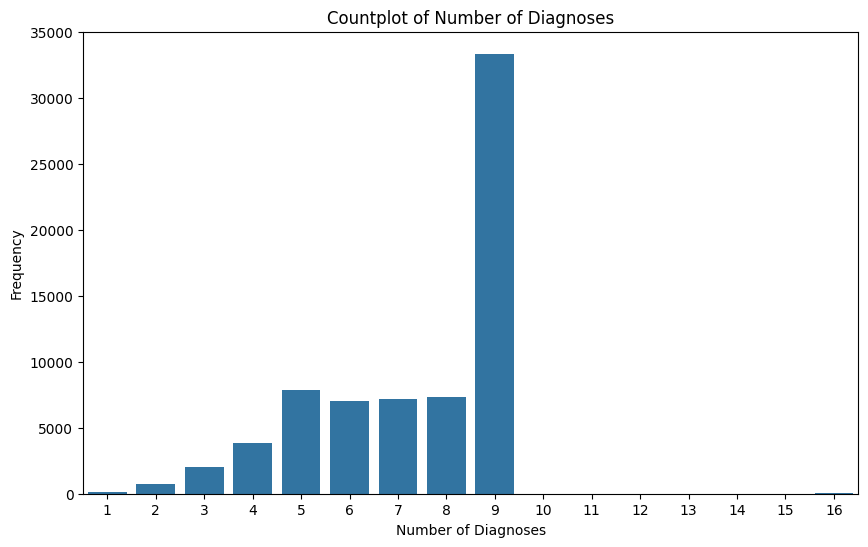

Minimum value of number_diagnoses: 1
Maximum value of number_diagnoses: 16


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# countplot for number_diagnoses
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='number_diagnoses')
plt.title('Countplot of Number of Diagnoses')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Frequency')
plt.show()

print("Minimum value of number_diagnoses:", df_train['number_diagnoses'].min())
print("Maximum value of number_diagnoses:", df_train['number_diagnoses'].max())


max_glu_serum

Norm - normal
None - no test conducted
Encoded and Indicator Feature

In [ ]:
df_train['max_glu_serum'] = df_train['max_glu_serum'].fillna('None')

In [ ]:
#
value_c= df_train['max_glu_serum'].value_counts()

print(value_c)


max_glu_serum
None    65975
Norm     1732
>200      978
>300      845
Name: count, dtype: int64


In [ ]:
# Original feature
df_train['max_glu_serum'] = df_train['max_glu_serum'].replace({
    'None': -99,  # Placeholder value for 'None'
    '>200': 1,
    '>300': 1,
    'Norm': 0
})

# indicator feature
df_train['max_glu_serum_not_taken'] = (df_train['max_glu_serum'] == -99).astype(int)


A1Cresult
6.5% or higher on two separate tests: indicate Diabetes

In [ ]:
df_train['A1Cresult'] = df_train['A1Cresult'].fillna('None')
value_count= df_train['A1Cresult'].value_counts()

print(value_count)

A1Cresult
None    57753
>8       5668
Norm     3445
>7       2664
Name: count, dtype: int64


In [ ]:
df_train['A1Cresult'] = df_train['A1Cresult'].replace({
    'None': -99,
    '>8': 1,
    '>7': 1,
    'Norm': 0
})

df_train['A1Cresult_not_taken'] = (df_train['A1Cresult'] == -99).astype(int)


number of medications - 23

In these features the values show whether a medication was prescribed or if there was a change in its dosage.

“Up”: Indicates that the dosage was increased during the encounter.

“Down”: Indicates that the dosage was decreased.

“Steady”: Indicates that the dosage remained unchanged.

“No”: Indicates that the medication was not prescribed.

In [ ]:
for c in df_train.columns:
    # Get unique values
    unique_vals = df_train[c].unique()

    # print the values or number of unique values based on the count
    if len(unique_vals) < 30:
        print(f"{c}: {unique_vals}")
    else:
        print(f"{c}: {len(unique_vals)} unique values")

gender: [1 0]
age: [60 90 50 80 70 40 30  0 10 20]
admission_type_id: [1 3 5]
discharge_disposition_id: ['Discharged to home' 'Transferred to Another Medical Facility'
 'Not Available' 'Left AMA (Against Medical Advice)'
 'Still Patient/Referred']
admission_source_id: ['Emergency' 'Referral' 'Not Available' 'Transfer' 'Court/Law Enforcement']
time_in_hospital: [ 3  5  9  7  8 11  2  1  6  4 13 14 10 12]
num_lab_procedures: 117 unique values
num_procedures: [6 0 2 3 4 1 5]
num_medications: 75 unique values
number_outpatient: 36 unique values
number_emergency: [ 0  2  1  3  5  4  7  6 13  9 10 18 22 15  8 19 14 12 20 11 54 76 16 46
 21 63 42 64 25]
number_inpatient: [ 2  1  0  7  4  3 15  5  6 12  8  9 10 13 11 16 14 18 21 19]
diag_1: [17. 12.  3.  5.  7.  8. 16.  9.  1. 10. 13.  0.  2.  4.  6. 11. 18. 14.]
diag_2: [ 3. 13.  7. 18.  4.  9. 16. 10.  8. 12.  0.  6. 17.  2. 11.  1.  5. 14.]
diag_3: [ 3. 18. 12.  5.  7.  0.  8. 10.  6.  2.  9. 16. 13.  4.  1. 17. 11. 14.]
number_diagnoses: [

Dropping
examide ['No']
citoglipton ['No'] , since it is not prescribed
Will keep metformin-pioglitazone ['No'] since it was in the original dataset with two values 'No' and 'Steady'


In [ ]:
df_train.drop(['examide', 'citoglipton'], axis = 1, inplace = True)

In [ ]:
medications = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']

for i in medications:
       print(i, df_train[i].unique())

metformin ['No' 'Steady' 'Up' 'Down']
repaglinide ['No' 'Steady' 'Up' 'Down']
nateglinide ['No' 'Steady' 'Up' 'Down']
chlorpropamide ['No' 'Steady' 'Up' 'Down']
glimepiride ['No' 'Steady' 'Up' 'Down']
acetohexamide ['No' 'Steady']
glipizide ['No' 'Steady' 'Up' 'Down']
glyburide ['No' 'Up' 'Steady' 'Down']
tolbutamide ['No' 'Steady']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
acarbose ['No' 'Steady' 'Up' 'Down']
miglitol ['No' 'Steady' 'Down' 'Up']
troglitazone ['No' 'Steady']
tolazamide ['No' 'Steady']
insulin ['Up' 'No' 'Steady' 'Down']
glyburide-metformin ['No' 'Steady' 'Down' 'Up']
glipizide-metformin ['No' 'Steady']
glimepiride-pioglitazone ['No' 'Steady']
metformin-rosiglitazone ['No' 'Steady']
metformin-pioglitazone ['No']


In [ ]:
for i in medications:
    df_train[i] = df_train[i].replace({'No': -2,
                           'Down': -1,
                           'Steady': 0,
                           'Up': 1})

change - Shows whether there was a change in diabetic medications

In [ ]:
df_train.change.value_counts()

,count
change,
No,37137
Ch,32393


In [ ]:
#encode change
df_train['change'] = df_train['change'].replace({'No' : 0, 'Ch' : 1})

diabetesMed - Shows if there was any diabetic medication prescribed

In [ ]:
df_train.diabetesMed.value_counts()

,count
diabetesMed,
Yes,53793
No,15737


In [ ]:
df_train['diabetesMed'] = df_train['diabetesMed'].replace({'Yes' : 1, 'No' : 0})

In [ ]:
df_train['total_visits']=df_train['number_outpatient']+df_train['number_emergency']+df_train['number_inpatient']

In [ ]:
# this copy has the 3 other columns'number_outpatient', 'number_emergency','number_inpatient' can test

df_train0 = df_train.copy()


In [ ]:
df_train = df_train.drop(columns=['number_outpatient', 'number_emergency','number_inpatient'])


In [ ]:
df_train.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK,max_glu_serum_not_taken,A1Cresult_not_taken,total_visits
0,1,60,1,Discharged to home,Emergency,3,49,6,27,17.0,3.0,3.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,1,1,2
1,0,90,3,Transferred to Another Medical Facility,Referral,5,57,0,21,12.0,3.0,18.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,1,1,1
2,1,50,5,Discharged to home,Not Available,9,61,6,27,3.0,13.0,12.0,9,-99,1,0,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,1,0,3
3,0,50,3,Discharged to home,Referral,7,23,0,13,5.0,7.0,5.0,7,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,0,-2,-2,-2,-2,0,1,0,0,1,0,0,0,1,1,3
4,1,50,1,Not Available,Referral,9,65,6,40,7.0,3.0,7.0,5,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,0,1,0,0,0,1,1,0


Medications changes in patients - new feature

In [ ]:
df_train['num_changes'] = np.nan
for i in range(len(df_train)):
    n = 0
    for j in medications:
        if df_train.loc[i, j] == -1 or df_train.loc[i, j] == 1:
            n += 1
    df_train.loc[i, 'num_changes'] = n

In [ ]:
df_train['num_changes'].value_counts()


,count
num_changes,
0.0,50495
1.0,18028
2.0,929
3.0,75
4.0,3


In [ ]:
df_train['number_diab_meds'] = np.nan

# iterate over each row to count non-"No" medications
for i in range(len(df_train)):
    n = 0
    for j in medications:
        if df_train.loc[i, j] != -2:
            n += 1
    df_train.loc[i, 'number_diab_meds'] = n

df_train['number_diab_meds'] = df_train['number_diab_meds'].astype('int64')

print(df_train['number_diab_meds'].value_counts())

number_diab_meds
1    32259
0    15737
2    15068
3     5490
4      934
5       38
6        4
Name: count, dtype: int64




```
# This is formatted as code
```

Created insulin_treatment

In [ ]:
df_train['insulin_treatment'] = np.nan

In [ ]:
for i in range(len(df_train)):
    if df_train.loc[i, 'insulin'] != -2 and df_train.loc[i, 'number_diab_meds'] == 1:
        df_train.loc[i, 'insulin_treatment'] = 'only_insulin'
    elif df_train.loc[i, 'insulin'] != -2 and df_train.loc[i, 'number_diab_meds'] > 1:
        df_train.loc[i, 'insulin_treatment'] = 'insulin_combo'
    elif df_train.loc[i, 'insulin'] == -2 and df_train.loc[i, 'number_diab_meds'] == 0:
        df_train.loc[i, 'insulin_treatment'] = 'no_meds'
    else:
        df_train.loc[i, 'insulin_treatment'] = 'other_meds'
df_train['insulin_treatment'].value_counts()

<ipython-input-75-564bfaa799c0>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'only_insulin' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train.loc[i, 'insulin_treatment'] = 'only_insulin'


,count
insulin_treatment,
only_insulin,20920
other_meds,16673
insulin_combo,16200
no_meds,15737


In [ ]:
insulin_treatment_mapping = {
    'only_insulin': 0,
    'insulin_combo': 1,
    'no_meds': 2,
    'other_meds': 3
}

df_train['insulin_treatment'] = df_train['insulin_treatment'].map(insulin_treatment_mapping)

# Verify the conversion
print(df_train['insulin_treatment'].value_counts())

insulin_treatment
0    20920
3    16673
1    16200
2    15737
Name: count, dtype: int64


In [ ]:
df_train.drop('number_diab_meds', axis=1, inplace=True)

In [ ]:
df_train.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK,diag_1_missing,diag_2_missing,diag_3_missing,max_glu_serum_not_taken,A1Cresult_not_taken,total_visits,num_changes,insulin_treatment
0,1,60,1,Discharged to home,Emergency,3,49,6,27,17.0,3.0,3.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,0,0,0,1,1,2,1.0,0
1,0,90,3,Transferred to Another Medical Facility,Referral,5,57,0,21,12.0,3.0,18.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,0,0,0,1,1,1,1.0,3
2,1,50,5,Discharged to home,Not Available,9,61,6,27,3.0,13.0,12.0,9,-99,1,0,-2,-2,-2,-2,-2,-2,1,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,0,0,0,1,0,3,1.0,3
3,0,50,3,Discharged to home,Referral,7,23,0,13,5.0,7.0,5.0,7,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,0,-2,-2,-2,-2,0,1,0,0,1,0,0,0,0,0,0,1,1,3,0.0,3
4,1,50,1,Not Available,Referral,9,65,6,40,7.0,3.0,7.0,5,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0.0,2


In [ ]:
df_train.reset_index(drop = True, inplace = True)

Statistical tests

In [ ]:
cat_cols = ['gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
    'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
    'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed', 'race_Asian', 'race_Caucasian',
    'race_Hispanic', 'race_Other', 'race_UNK', 'max_glu_serum_not_taken',
    'A1Cresult_not_taken', 'insulin_treatment','diag_1', 'diag_2', 'diag_3']

In [ ]:
num_cols = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_diagnoses','total_visits', 'num_changes']

In [ ]:
#Statistical Tests (Chi Square and Anova)

p_value = []
sig = []
for i in df_train.columns:
    if i in num_cols:
        stat, p = stats.f_oneway(df_train[df_train['readmitted'] == 0][i], df_train[df_train['readmitted'] == 1][i])
    else:
        ct = pd.crosstab(df_train[i], df_train['readmitted'])
        stat, p, dof, exp = stats.chi2_contingency(ct)
    p_value.append(p)
    if p < 0.05:
        sig.append('Significant')
    else:
        sig.append("Insignificant")
stats_df_train = pd.DataFrame({"columns" : df_train.columns, "p_value" : p_value, "significance" : sig})

stats_df_train.sort_values(by='p_value',ascending = True)

,columns,p_value,significance
38,readmitted,0.000000e+00,Significant
49,total_visits,1.367593e-238,Significant
3,discharge_disposition_id,2.228697e-114,Significant
12,number_diagnoses,1.120083e-48,Significant
5,time_in_hospital,2.061184e-34,Significant
10,diag_2,3.455729e-31,Significant
11,diag_3,4.940674e-28,Significant
8,num_medications,3.674293e-27,Significant
30,insulin,4.224926e-26,Significant
51,insulin_treatment,2.945399e-24,Significant


In [ ]:
sig_cols = stats_df_train[stats_df_train['significance'] == 'Significant']['columns'].reset_index(drop = True)
insig_cols = stats_df_train[stats_df_train['significance'] == 'Insignificant']['columns'].reset_index(drop = True)
print('Statiscally significant features are :','\n')
print(sig_cols)

Statiscally significant features are : 

0                          age
1            admission_type_id
2     discharge_disposition_id
3          admission_source_id
4             time_in_hospital
5           num_lab_procedures
6               num_procedures
7              num_medications
8                       diag_1
9                       diag_2
10                      diag_3
11            number_diagnoses
12               max_glu_serum
13                   A1Cresult
14                   metformin
15                 repaglinide
16                 glimepiride
17                   glipizide
18                     insulin
19                      change
20                 diabetesMed
21                  readmitted
22              race_Caucasian
23                    race_UNK
24              diag_2_missing
25              diag_3_missing
26     max_glu_serum_not_taken
27         A1Cresult_not_taken
28                total_visits
29                 num_changes
30           insulin_treatmen

In [ ]:
insig_meds = ["rosiglitazone", "acarbose",
              "glyburide", "nateglinide", "chlorpropamide",
              "glyburide-metformin", "pioglitazone", "miglitol",
              "tolazamide", "tolbutamide", "glimepiride-pioglitazone",
              "metformin-rosiglitazone", "metformin-pioglitazone",
            "troglitazone", "acetohexamide", "glipizide-metformin"]

In [ ]:
len(medications)

21

In [ ]:

# Medicines given to less than 1% of the population i.e. less than 485 people
count = []

for i in medications:
    print(df_train[i].value_counts(), '\n')

    vc = df_train[i].value_counts().values
    if vc[1:].sum() / vc[0] < 0.01:
        count.append(i)

metformin
-2    55621
 0    12748
 1      758
-1      403
Name: count, dtype: int64 

repaglinide
-2    68441
 0      977
 1       78
-1       34
Name: count, dtype: int64 

nateglinide
-2    69073
 0      431
 1       18
-1        8
Name: count, dtype: int64 

chlorpropamide
-2    69477
 0       48
 1        4
-1        1
Name: count, dtype: int64 

glimepiride
-2    65923
 0     3236
 1      239
-1      132
Name: count, dtype: int64 

acetohexamide
-2    69529
 0        1
Name: count, dtype: int64 

glipizide
-2    60702
 0     7910
 1      550
-1      368
Name: count, dtype: int64 

glyburide
-2    62170
 0     6412
 1      550
-1      398
Name: count, dtype: int64 

tolbutamide
-2    69516
 0       14
Name: count, dtype: int64 

pioglitazone
-2    64386
 0     4902
 1      164
-1       78
Name: count, dtype: int64 

rosiglitazone
-2    65083
 0     4262
 1      121
-1       64
Name: count, dtype: int64 

acarbose
-2    69313
 0      206
 1        9
-1        2
Name: count, dtype: i

In [ ]:
count, len(count)

(['nateglinide',
  'chlorpropamide',
  'acetohexamide',
  'tolbutamide',
  'acarbose',
  'miglitol',
  'troglitazone',
  'tolazamide',
  'glyburide-metformin',
  'glipizide-metformin',
  'glimepiride-pioglitazone',
  'metformin-rosiglitazone',
  'metformin-pioglitazone'],
 13)

In [ ]:
df_train= df_train.drop(['nateglinide',
  'chlorpropamide',
  'acetohexamide',
  'tolbutamide',
  'acarbose',
  'miglitol',
  'troglitazone',
  'tolazamide',
  'glyburide-metformin',
  'glipizide-metformin',
  'glimepiride-pioglitazone',
  'metformin-rosiglitazone',
  'metformin-pioglitazone'],axis=1)

In [ ]:
df_train.shape

(69530, 39)

In [ ]:
df_train.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK,max_glu_serum_not_taken,A1Cresult_not_taken,total_visits,num_changes,insulin_treatment
0,1,60,1,Discharged to home,Emergency,3,49,6,27,17.0,3.0,3.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,1,1,1,0,0,1,0,0,0,1,1,2,1,0
1,0,90,3,Transferred to Another Medical Facility,Referral,5,57,0,21,12.0,3.0,18.0,9,-99,-99,-2,-2,-2,-2,1,-2,-2,-2,1,1,0,0,1,0,0,0,1,1,1,1,3
2,1,50,5,Discharged to home,Not Available,9,61,6,27,3.0,13.0,12.0,9,-99,1,0,-2,-2,-2,1,-2,-2,-2,1,1,0,0,1,0,0,0,1,0,3,1,3
3,0,50,3,Discharged to home,Referral,7,23,0,13,5.0,7.0,5.0,7,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,0,1,0,0,1,0,0,0,1,1,3,0,3
4,1,50,1,Not Available,Referral,9,65,6,40,7.0,3.0,7.0,5,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,0,1,0,0,0,1,1,0,0,2


In [ ]:
df_train['num_changes'] = df_train['num_changes'].astype(int)


Since both the change and number_changes features represent similar information and both are significant. Choosing to keep number_changes because it has a slightly lower p-value, indicating greater significance.

In [ ]:
df_train = df_train.drop(['change'],axis=1)

In [ ]:
# dropping the columns
df_train.drop(columns=['diag_1_missing', 'diag_2_missing', 'diag_3_missing'], inplace=True)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_train_.csv to diabetes_train_.csv


In [ ]:
df_train = pd.read_csv('diabetes_train_.csv')
df_train.head(30)

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK,max_glu_serum_not_taken,A1Cresult_not_taken,total_visits,num_changes,insulin_treatment
0,1,60,1,Discharged to home,Emergency,3,49,6,27,17.0,3.0,3.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,1,1,2,1,0
1,0,90,3,Transferred to Another Medical Facility,Referral,5,57,0,21,12.0,3.0,18.0,9,-99,-99,-2,-2,-2,-2,1,-2,-2,-2,1,0,0,1,0,0,0,1,1,1,1,3
2,1,50,5,Discharged to home,Not Available,9,61,6,27,3.0,13.0,12.0,9,-99,1,0,-2,-2,-2,1,-2,-2,-2,1,0,0,1,0,0,0,1,0,3,1,3
3,0,50,3,Discharged to home,Referral,7,23,0,13,5.0,7.0,5.0,7,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,1,0,0,1,0,0,0,1,1,3,0,3
4,1,50,1,Not Available,Referral,9,65,6,40,7.0,3.0,7.0,5,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,1,0,0,0,1,1,0,0,2
5,1,60,1,Not Available,Emergency,8,47,2,17,7.0,18.0,7.0,4,-99,-99,-2,-2,-2,0,-2,-2,-2,-2,1,0,0,1,0,0,0,1,1,0,0,3
6,1,80,3,Transferred to Another Medical Facility,Referral,11,35,2,34,8.0,7.0,0.0,5,-99,-99,-2,-2,-2,-2,-2,0,-2,1,1,0,0,1,0,0,0,1,1,2,1,1
7,1,70,1,Discharged to home,Emergency,2,22,2,10,7.0,7.0,7.0,6,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,1,0,0,0,1,1,0,0,2
8,1,60,1,Not Available,Emergency,2,43,0,11,7.0,7.0,0.0,4,-99,-99,0,-2,-2,-2,-2,-2,-2,-2,1,0,0,1,0,0,0,1,1,0,0,3
9,1,80,1,Discharged to home,Emergency,3,50,0,19,16.0,4.0,18.0,9,-99,-99,-2,-2,-2,0,-2,-2,-2,0,1,0,0,0,0,0,0,1,1,0,0,1


admission_type_id mapped as  'Emergency': 1, 'Not Available': 5, 'Elective': 3

dmission_source_id categories: Emergency, Referral, Transfer, Not Available
Court/Law Enforcement

In [ ]:
df_train['admission_source_id'].value_counts()

,count
admission_source_id,
Emergency,39848
Referral,21350
Transfer,4329
Not Available,3990
Court/Law Enforcement,13


In [ ]:
df_train['admission_source_id']=df_train['admission_source_id'].replace({'Emergency': 1,
    'Referral': 3,
    'Transfer': 4,
    'Not Available': 5,
    'Court/Law Enforcement': 2})

In [ ]:
df_train['admission_type_id'].value_counts()

,count
admission_type_id,
1,49448
3,13036
5,7046


In [ ]:
# Calculate the Pearson correlation between admission_type_id and admission_source_id
correlation = df_train['admission_type_id'].corr(df_train['admission_source_id'])

print(f"Correlation between admission_type_id and admission_source_id: {correlation}")


Correlation between admission_type_id and admission_source_id: 0.6233645706378688


In [ ]:
df_train0 = df_train.copy()

In [ ]:
df_train= df_train.drop(['admission_type_id'],axis=1)

In [ ]:
df_train['admission_source_id']=df_train['admission_source_id'].replace({'Emergency': 1,
    'Referral': 3,
    'Transfer': 4,
    'Not Available': 5,
    'Court/Law Enforcement': 2})

In [ ]:
print(df_train['discharge_disposition_id'].value_counts())

discharge_disposition_id
Discharged to home                         51138
Transferred to Another Medical Facility    14596
Not Available                               3291
Left AMA (Against Medical Advice)            432
Still Patient/Referred                        73
Name: count, dtype: int64


In [ ]:
df_train['discharge_disposition_id']=df_train['discharge_disposition_id'].replace({ 'Discharged to home': 1,
    'Transferred to Another Medical Facility': 2,
    'Left AMA (Against Medical Advice)': 7,
    'Still Patient/Referred': 9,
    'Not Available': 18})

In [ ]:
df_train.shape

(69530, 34)

In [ ]:
df_train.head()

,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_UNK,diag_1_missing,diag_2_missing,diag_3_missing,max_glu_serum_not_taken,A1Cresult_not_taken,total_visits,num_changes,insulin_treatment
0,1,60,1,1,3,49,6,27,17.0,3.0,3.0,9,-99,-99,-2,-2,-2,-2,-2,-2,-2,1,1,0,0,1,0,0,0,0,0,0,1,1,2,1,0
1,0,90,2,3,5,57,0,21,12.0,3.0,18.0,9,-99,-99,-2,-2,-2,-2,1,-2,-2,-2,1,0,0,1,0,0,0,0,0,0,1,1,1,1,3
2,1,50,1,5,9,61,6,27,3.0,13.0,12.0,9,-99,1,0,-2,-2,-2,1,-2,-2,-2,1,0,0,1,0,0,0,0,0,0,1,0,3,1,3
3,0,50,1,3,7,23,0,13,5.0,7.0,5.0,7,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,1,0,0,1,0,0,0,0,0,0,1,1,3,0,3
4,1,50,18,3,9,65,6,40,7.0,3.0,7.0,5,-99,-99,-2,-2,-2,-2,-2,-2,-2,-2,0,0,0,1,0,0,0,0,0,0,1,1,0,0,2


In [ ]:
df_train.columns


Index(['gender', 'age', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride',
       'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin',
       'diabetesMed', 'readmitted', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Other', 'race_UNK', 'max_glu_serum_not_taken',
       'A1Cresult_not_taken', 'total_visits', 'num_changes',
       'insulin_treatment'],
      dtype='object')

Data Type Conversion

In [ ]:
cat = ['gender',
    'age', 'discharge_disposition_id','admission_source_id', 'diag_1', 'diag_2','diag_3',
    'max_glu_serum','A1Cresult','metformin','repaglinide','glimepiride','glipizide','glyburide',
    'pioglitazone','rosiglitazone','insulin',
    'diabetesMed', 'race_Asian','race_Caucasian', 'race_Hispanic','race_Other','race_UNK',
    'max_glu_serum_not_taken','A1Cresult_not_taken','num_changes','insulin_treatment'
]


In [ ]:
df_train.shape

(69530, 34)

In [ ]:
for i in df_train.columns:
    if df_train[i].dtype==object:
        d= df_train[i].value_counts()
        print(pd.DataFrame(data=d))

In [ ]:
# Get the list of the numerical variable
num = list(set(list(df_train._get_numeric_data().columns))- {'readmitted'})
num

['metformin',
 'max_glu_serum_not_taken',
 'time_in_hospital',
 'race_Caucasian',
 'A1Cresult',
 'insulin_treatment',
 'gender',
 'race_Other',
 'number_diagnoses',
 'insulin',
 'glyburide',
 'admission_source_id',
 'diag_1',
 'rosiglitazone',
 'num_medications',
 'age',
 'num_procedures',
 'glimepiride',
 'race_Asian',
 'repaglinide',
 'num_changes',
 'discharge_disposition_id',
 'glipizide',
 'total_visits',
 'max_glu_serum',
 'num_lab_procedures',
 'A1Cresult_not_taken',
 'diag_2',
 'race_Hispanic',
 'diag_3',
 'pioglitazone',
 'diabetesMed',
 'race_UNK']

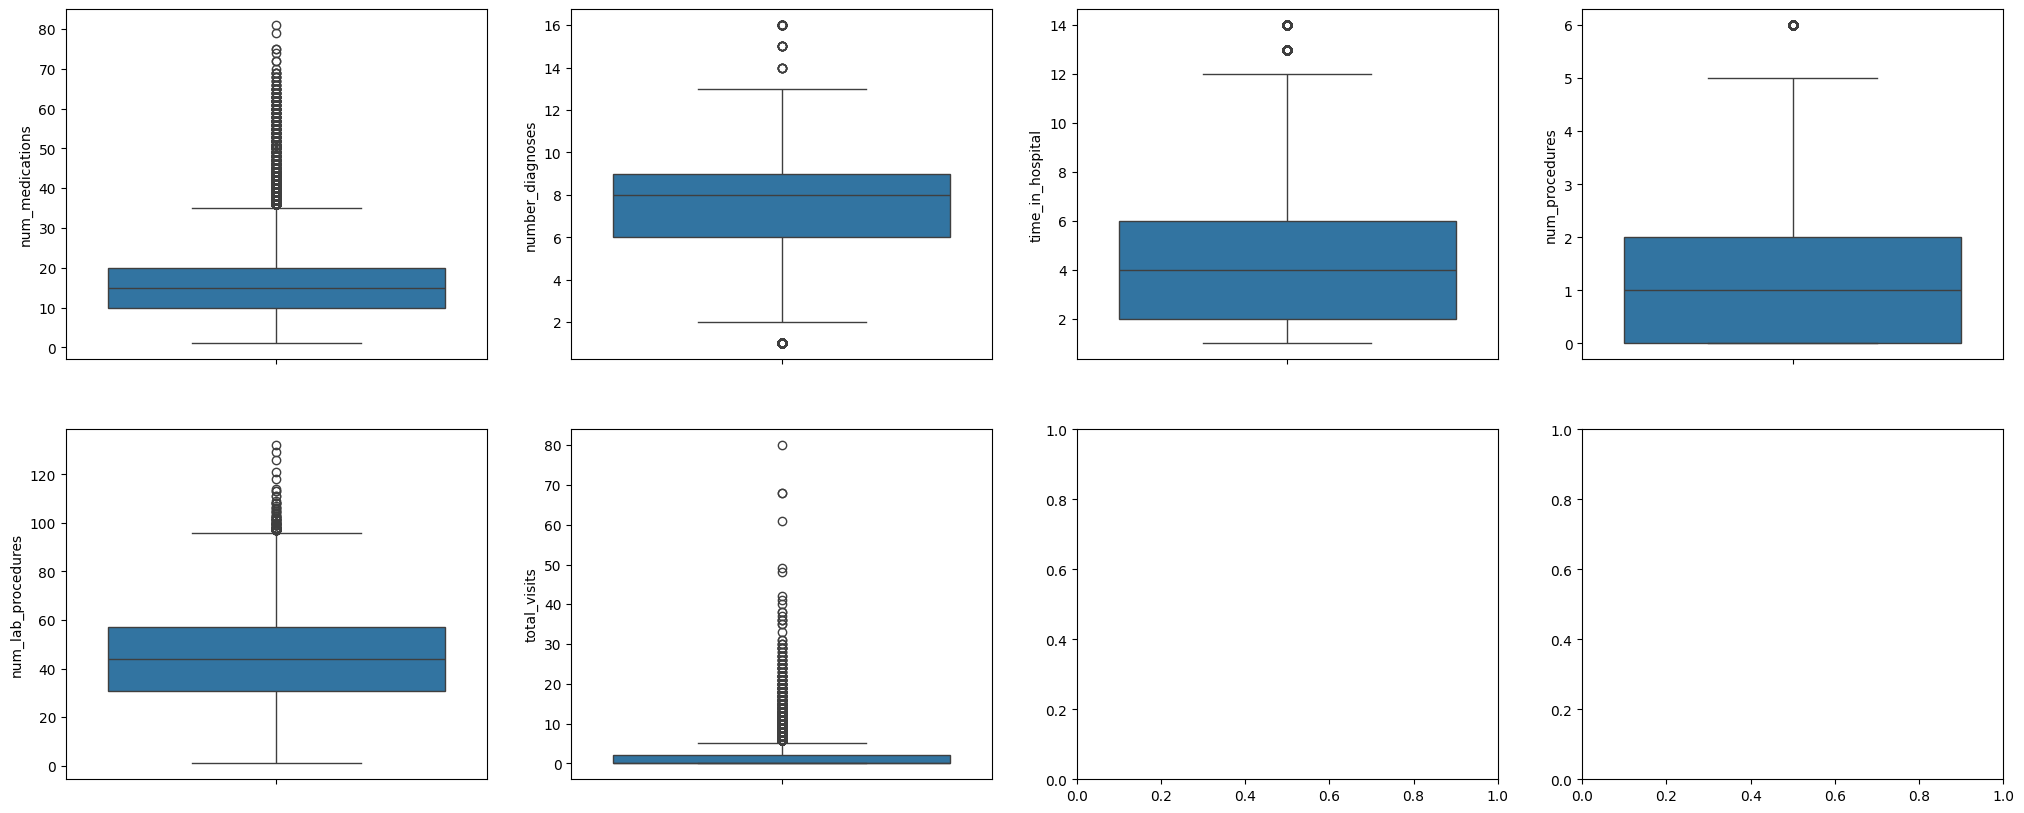

In [ ]:

cols = ['num_medications',
 'number_diagnoses',
 'time_in_hospital',
 'num_procedures',
 'num_lab_procedures',
 'total_visits']

fig,ax=plt.subplots(2,4,figsize=(25,10))
ax=ax.flatten()
j=0
for i in cols:
    sns.boxplot(df_train[i],ax=ax[j])
    j=j+1
plt.show()



Outliers

In [ ]:
num_cols = ['num_medications',
            'number_diagnoses',
            'time_in_hospital',
            'num_procedures',
            'num_lab_procedures',
            'total_visits']

df_num = df_train[num_cols]

# calculate Z-scores
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))

# identify outliers using a Z-score threshold
threshold = 3
outliers = (z_scores > threshold)

# count the number of outliers in each column
num_outliers = np.sum(outliers, axis=0)

print("Number of outliers in each feature:")
for col, count in zip(num_cols, num_outliers):
    print(f"{col}: {count}")


outlier_indices = np.where(np.any(outliers, axis=1))[0]
print("\nSample rows with outliers:")
print(df_train.iloc[outlier_indices].head())

Number of outliers in each feature:
num_medications: 929
number_diagnoses: 196
time_in_hospital: 683
num_procedures: 0
num_lab_procedures: 32
total_visits: 1162

Sample rows with outliers:
    gender  age  discharge_disposition_id  admission_source_id  \
34       0   30                         1                    1   
61       1   70                         1                    1   
67       0   10                         1                    1   
93       1   70                         1                    4   
95       0   80                         2                    4   

    time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
34                 2                  48               2               21   
61                14                  77               6               35   
67                 2                  63               1                2   
93                10                  66               6               48   
95                14         

In [ ]:
#Number of outliers
for i in cols:
    q1 = df_train[i].quantile(0.25)
    q3 = df_train[i].quantile(0.75)
    iqr = q3-q1

    UL = q3 + (1.5 * iqr)
    LL = q1 - (1.5 * iqr)
    print(i,df_train[(df_train[i]>UL) | (df_train[i]<LL)].count()[i])
    #print(X[(X[i]>UL) | (X[i]<LL)][i])

num_medications 1707
number_diagnoses 196
time_in_hospital 1513
num_procedures 3360
num_lab_procedures 88
total_visits 3005


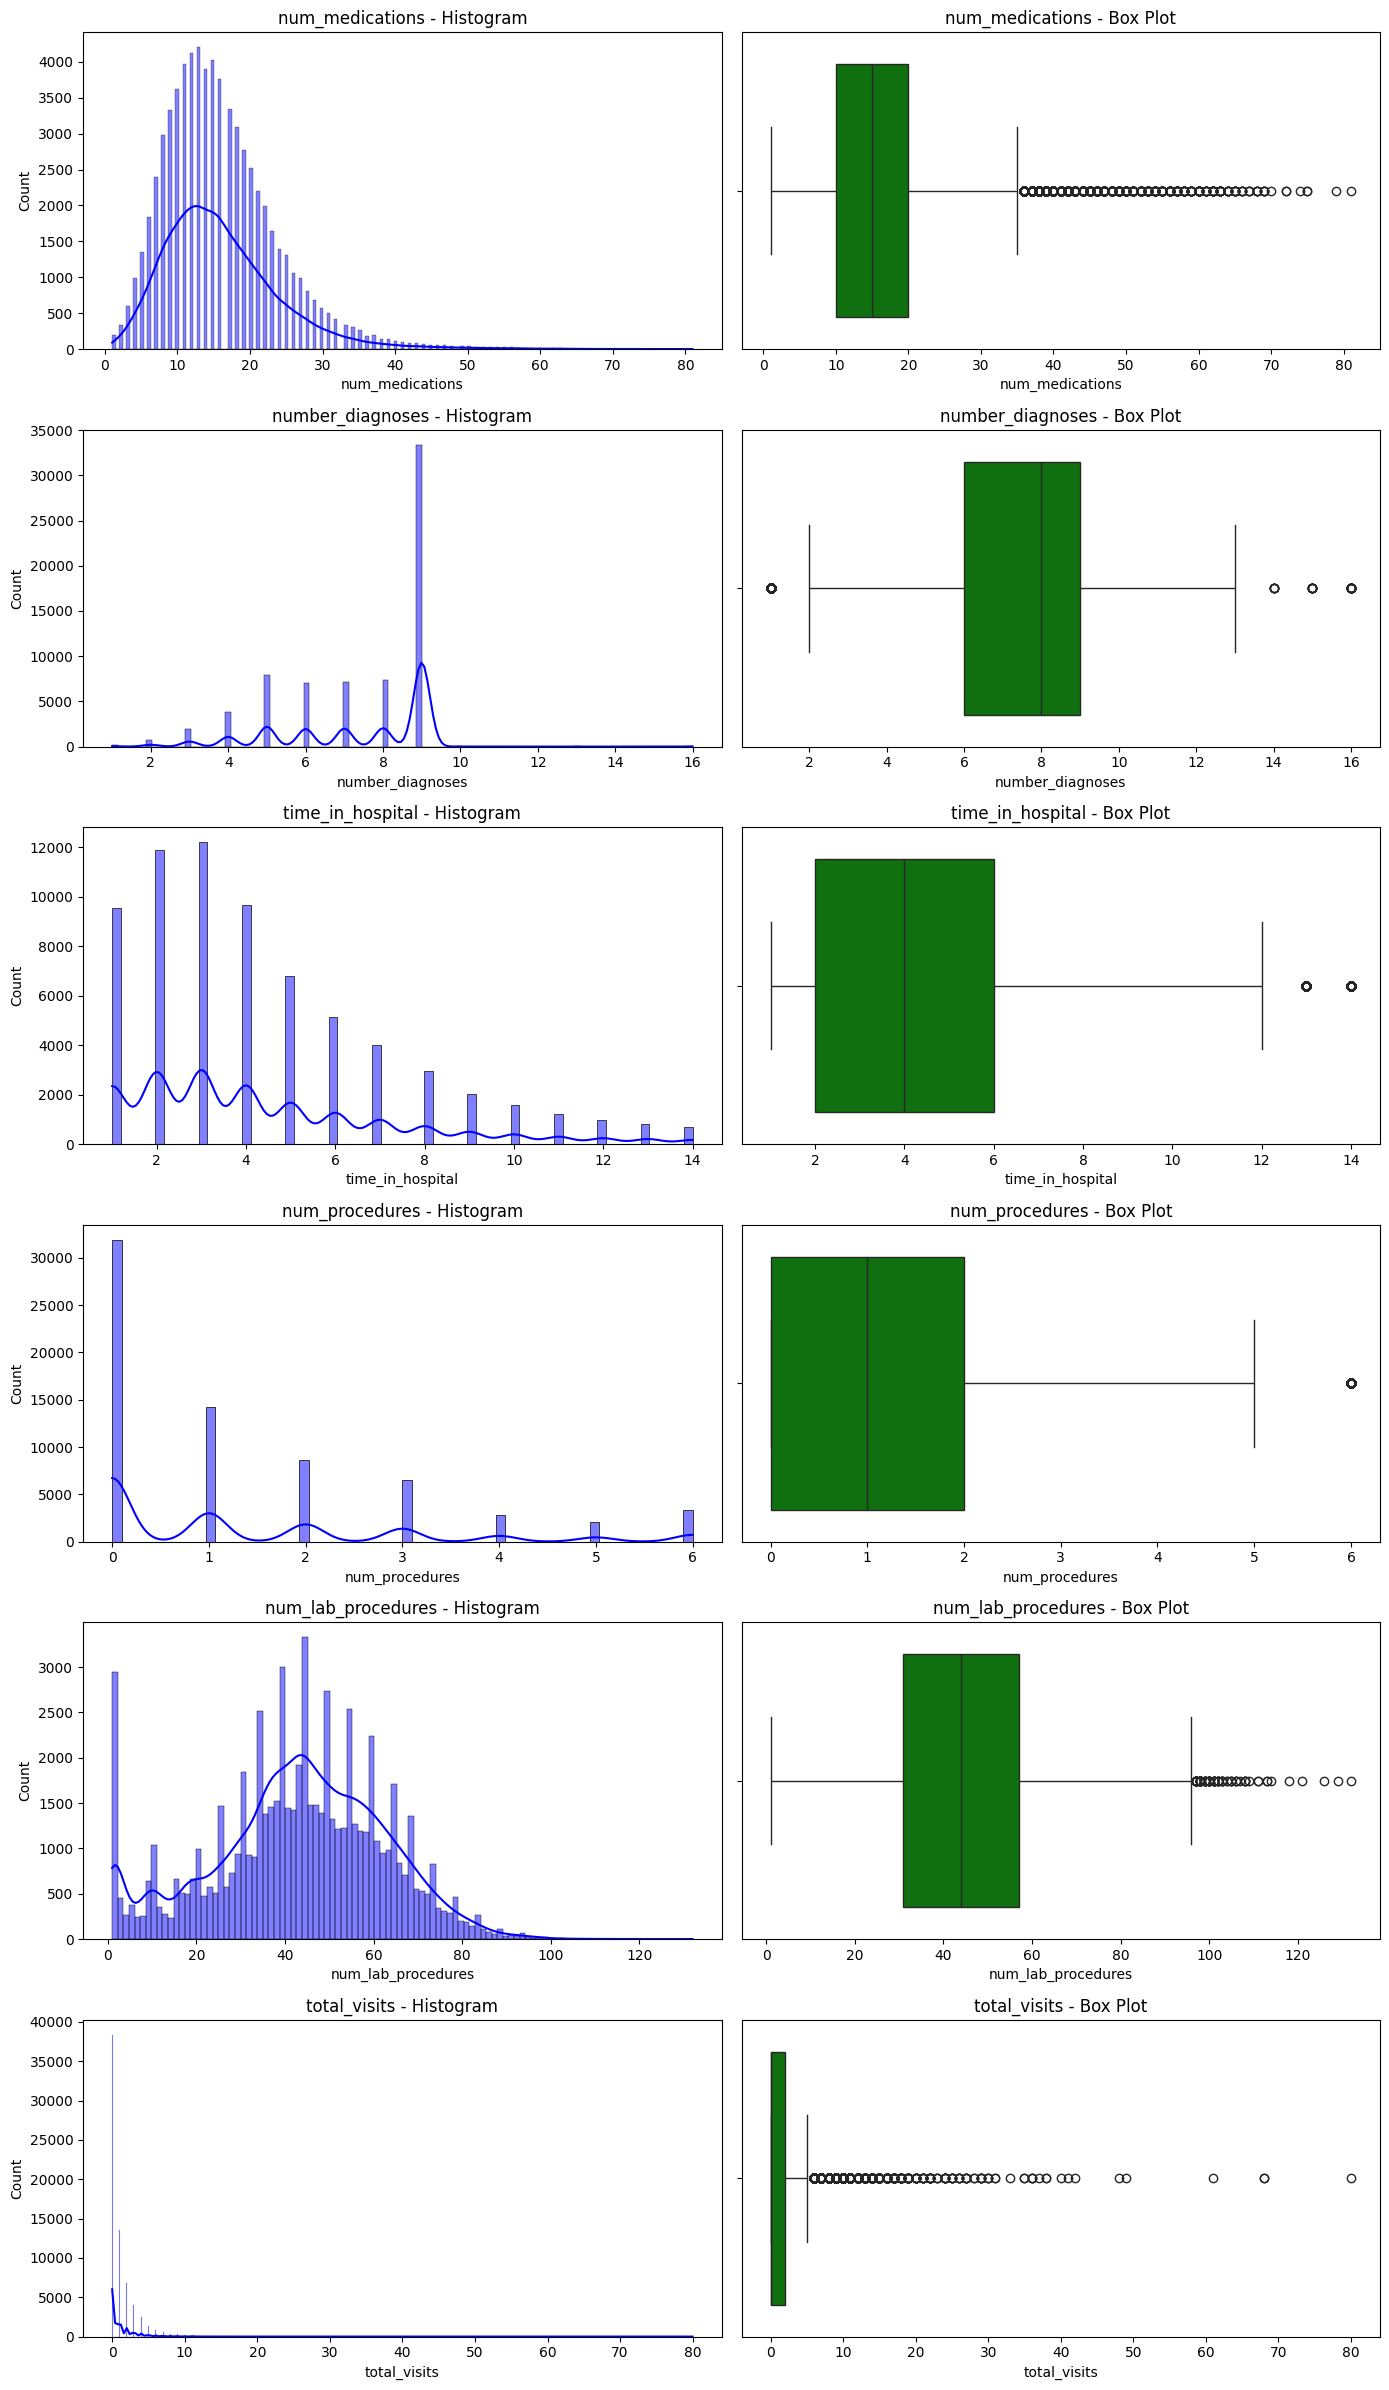

In [ ]:
# List of features to visualize from df_train
features = ['num_medications', 'number_diagnoses', 'time_in_hospital', 'num_procedures', 'num_lab_procedures', 'total_visits']

# Set up the figure and axes
fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(14, len(features)*4))

for i, feature in enumerate(features):
    # Histogram
    sns.histplot(df_train[feature], ax=axes[i, 0], kde=True, color='blue')
    axes[i, 0].set_title(f'{feature} - Histogram')

    # Box plot
    sns.boxplot(x=df_train[feature], ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'{feature} - Box Plot')

plt.tight_layout()
plt.show()


Skweness

In [ ]:
from scipy import stats
cols = ['num_medications',
 'number_diagnoses',
 'time_in_hospital',
 'num_procedures',
 'num_lab_procedures',
 'total_visits']

print(df_train[cols].skew())
print(df_train[cols].kurt())

num_medications       1.340546
number_diagnoses     -0.861429
time_in_hospital      1.144307
num_procedures        1.318594
num_lab_procedures   -0.235150
total_visits          5.682458
dtype: float64
num_medications        3.580249
number_diagnoses      -0.130036
time_in_hospital       0.894619
num_procedures         0.863756
num_lab_procedures    -0.238575
total_visits          80.844602
dtype: float64


Skewness measures the asymmetry of the data distribution around its mean.

Negative Skew: The left tail is longer or fatter than the right tail.
Positive Skew: The right tail is longer or fatter than the left tail.
Zero Skew: The distribution is symmetric.
Thresholds for Skewness:

Near 0: Data is approximately normally distributed.
|Skewness| < 0.5: Fairly symmetric.
0.5 ≤ |Skewness| < 1: Moderately skewed.
|Skewness| ≥ 1: Highly skewed.

num_medications: 1.352 (Positive skew, moderately skewed)

number_diagnoses: -0.915 (Negative skew, moderately skewed)

time_in_hospital: 1.123 (Positive skew, moderately skewed)

num_procedures: 1.492 (Positive skew, highly skewed)

num_lab_procedures: -0.272 (Near symmetric)

total_visits: 4.794 (Positive skew, highly skewed)





Kurtosis measures the "tailedness" of the distribution.

Leptokurtic: High peak and heavy tails (kurtosis > 3).
Platykurtic: Flat peak and light tails (kurtosis < 3).
Mesokurtic: Normal peak (kurtosis = 3).

Kurtosis ≈ 3: Normally distributed.
Kurtosis > 3: Heavy tails (leptokurtic).
Kurtosis < 3: Light tails (platykurtic).


num_medications: 3.707 (Leptokurtic, heavy tails)

number_diagnoses: 0.053 (Platykurtic, light tails)

time_in_hospital: 0.919 (Platykurtic, light tails)

num_procedures: 1.535 (Platykurtic, light tails)

num_lab_procedures: -0.195 (Platykurtic, light tails)

total_visits: 52.689 (Leptokurtic, heavy tails)

In [ ]:
from sklearn.preprocessing import PowerTransformer


# Calculate skewness before transformation
skew_before = df_train[cols].skew()

# Apply Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
df_train[cols] = pd.DataFrame(pt.fit_transform(df_train[cols]), columns=cols)

# Calculate skewness after transformation
skew_after = df_train[cols].skew()

# Combine the results into a DataFrame for comparison
skew_df = pd.DataFrame({
    "Skew_Before": skew_before,
    "Skew_After": skew_after
})

print(skew_df)

                    Skew_Before  Skew_After
num_medications        1.340546    0.020469
number_diagnoses      -0.861429   -0.158321
time_in_hospital       1.144307    0.013009
num_procedures         1.318594    0.208165
num_lab_procedures    -0.235150   -0.224922
total_visits           5.682458    0.420815


In [ ]:
num_cols = ['num_medications',
            'number_diagnoses',
            'time_in_hospital',
            'num_procedures',
            'num_lab_procedures',
            'total_visits']

# Subset the DataFrame to only include numerical columns
df_num = df_train[num_cols]

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))

# Identify outliers using a Z-score threshold
threshold = 3
outliers = (z_scores > threshold)

# Count the number of outliers in each column
num_outliers = np.sum(outliers, axis=0)

print("Number of outliers in each feature:")
for col, count in zip(num_cols, num_outliers):
    print(f"{col}: {count}")

# Display some sample rows with outliers for review
outlier_indices = np.where(np.any(outliers, axis=1))[0]
print("\nSample rows with outliers:")
print(df_train.iloc[outlier_indices].head())

Number of outliers in each feature:
num_medications: 458
number_diagnoses: 59
time_in_hospital: 0
num_procedures: 0
num_lab_procedures: 32
total_visits: 0

Sample rows with outliers:
     gender  age  discharge_disposition_id  admission_source_id  \
210       0   60                         1                    5   
235       1   30                         1                    5   
265       1   40                         2                    3   
738       1   60                         1                    1   
745       0   60                         2                    1   

     time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
210          0.491340            1.642954        1.394281         3.030909   
235          1.223493            3.082678        0.310305         1.402581   
265          2.106532            0.668100        1.182559         3.085826   
738          0.152787            0.258292       -1.013779         0.635751   
745         -0.827692   

In [ ]:

out_cols = ['num_medications', 'number_diagnoses',  'num_lab_procedures', ]


z_scores = np.abs(stats.zscore(df_train[out_cols]))


# Remove outliers based on Z-score threshold of 3
df_train = df_train[(z_scores < 3).all(axis=1)]


Scaling

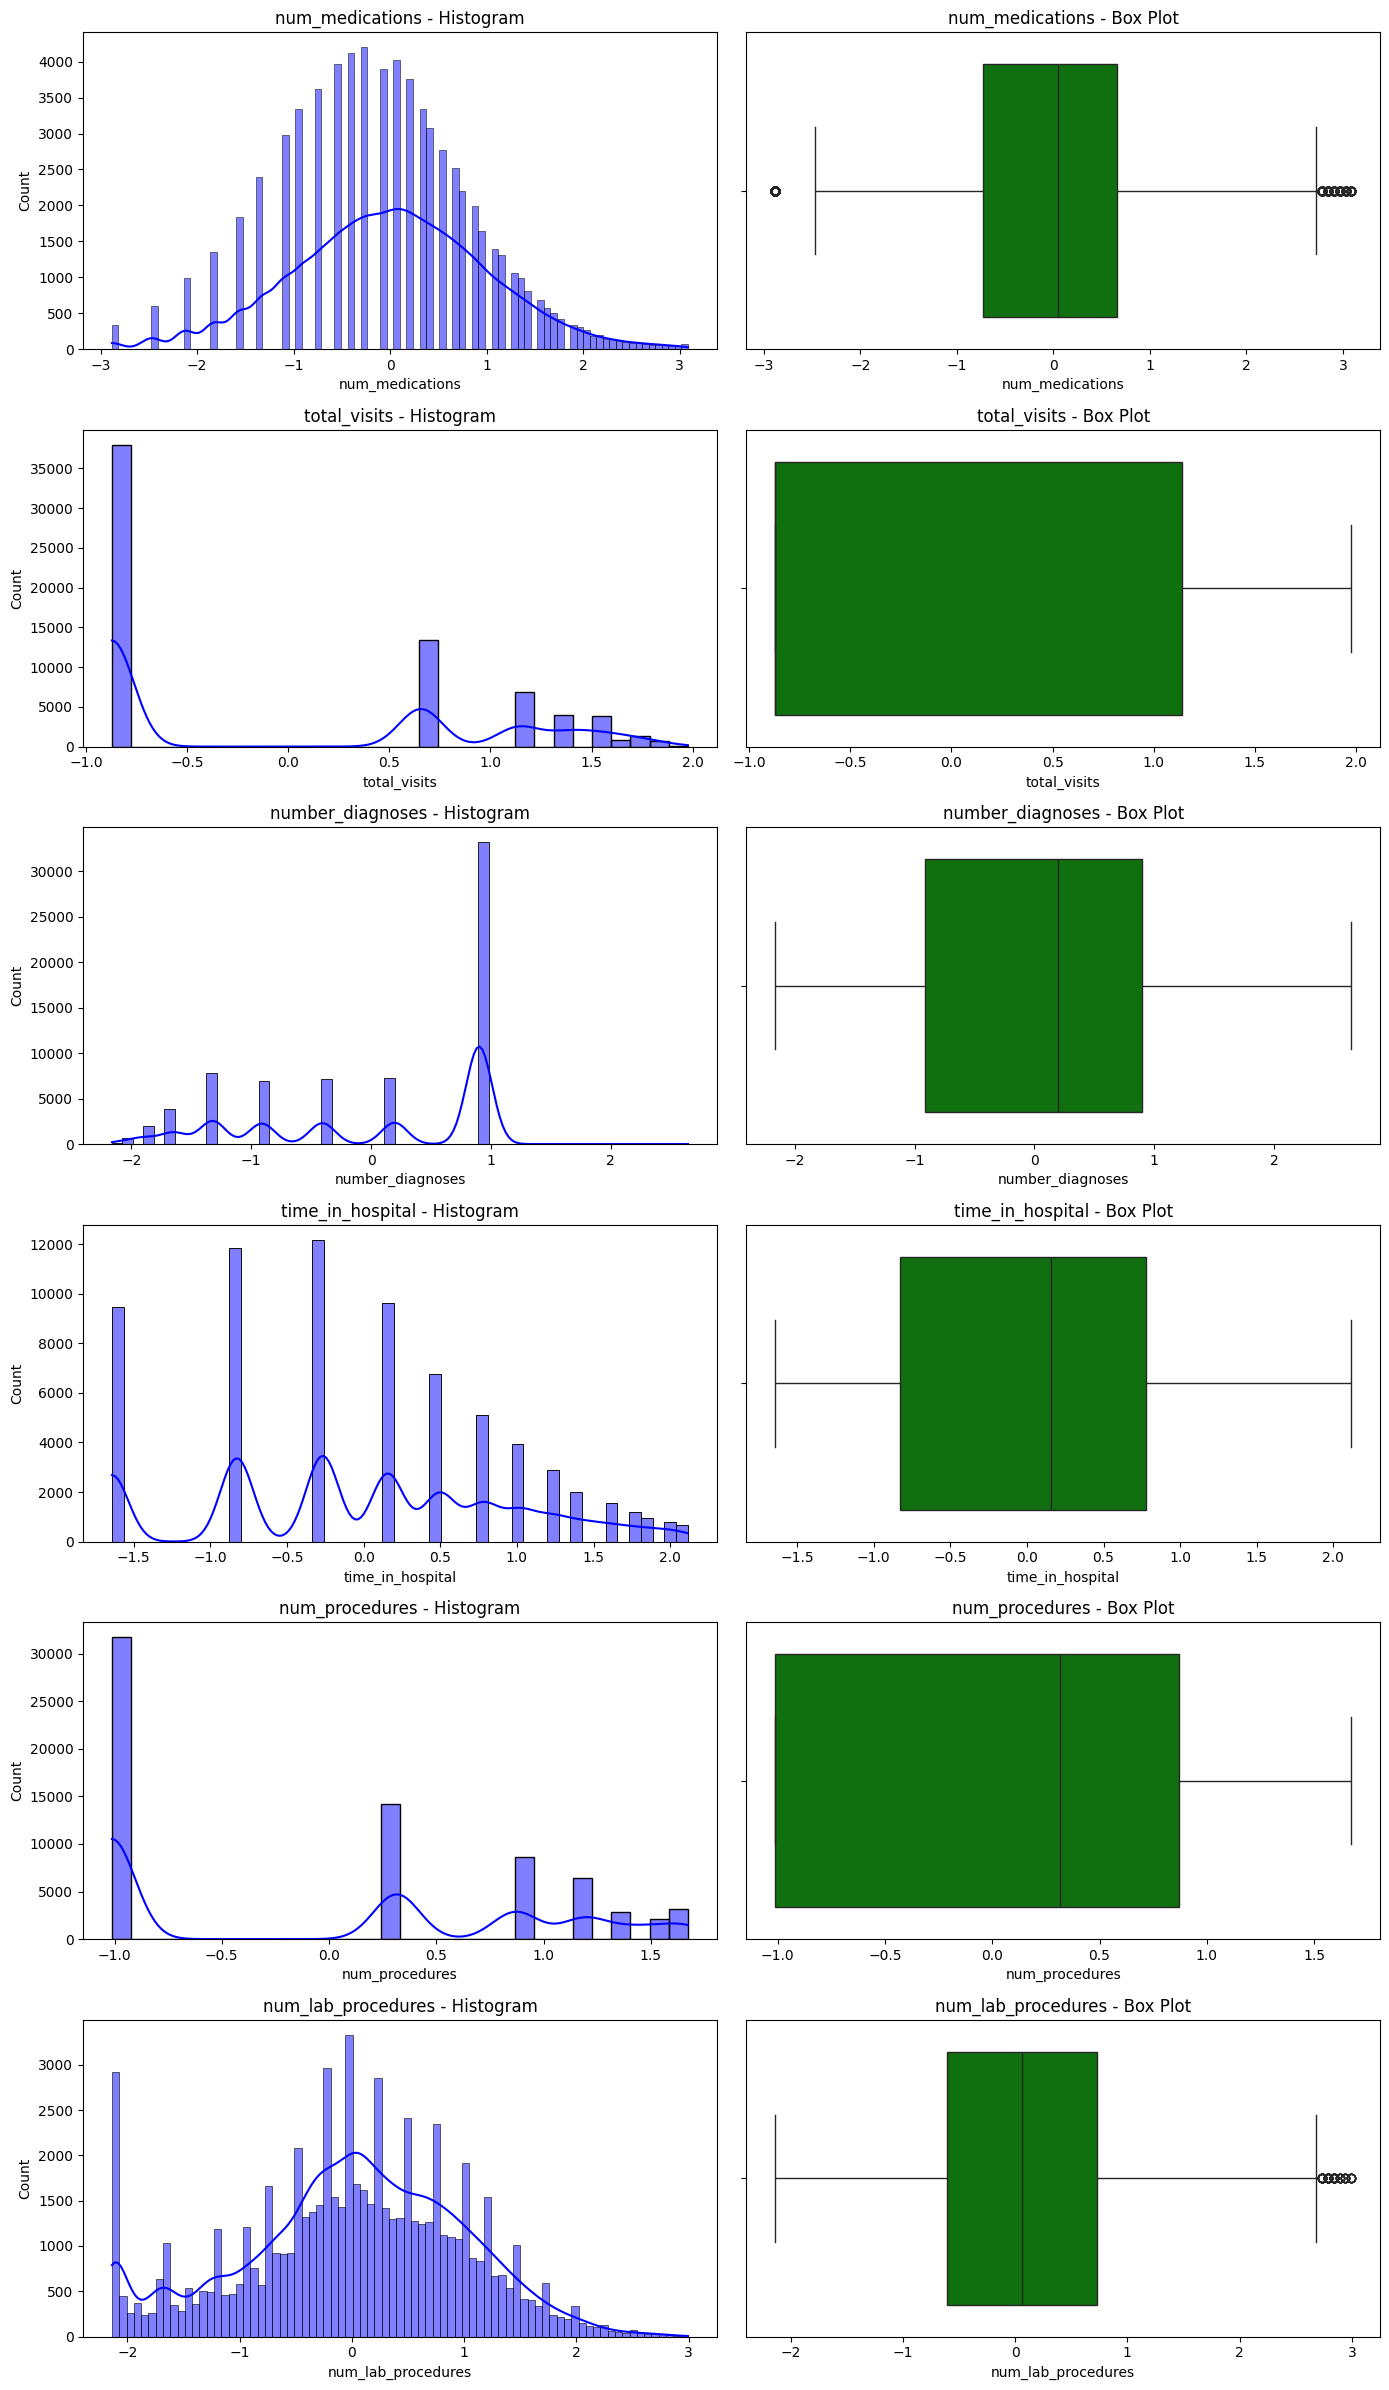

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to analyze
features = ['num_medications', 'total_visits', 'number_diagnoses', 'time_in_hospital', 'num_procedures', 'num_lab_procedures']

fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(14, len(features) * 4))

for i, feature in enumerate(features):
    # Histogram
    sns.histplot(df_train[feature], ax=axes[i, 0], kde=True, color='blue')
    axes[i, 0].set_title(f'{feature} - Histogram')

    # Box plot
    sns.boxplot(x=df_train[feature], ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'{feature} - Box Plot')

plt.tight_layout()
plt.show()


In [ ]:
import joblib
scaler = StandardScaler()

# fit the scaler on the training data and transform it
df_train[cols] = scaler.fit_transform(df_train[cols])



joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
# Calculate mean and standard deviation
print(df_train[cols].mean())
print(df_train[cols].std())

num_medications      -5.109613e-19
number_diagnoses     -8.788534e-18
time_in_hospital     -4.803036e-18
num_procedures        2.043845e-17
num_lab_procedures    2.656999e-18
total_visits         -5.211805e-18
dtype: float64
num_medications       1.000007
number_diagnoses      1.000007
time_in_hospital      1.000007
num_procedures        1.000007
num_lab_procedures    1.000007
total_visits          1.000007
dtype: float64


In [ ]:
from scipy.stats import skew

# Calculate skewness for each feature
skewness = df_train[features].apply(lambda x: skew(x.dropna()))
print("Skewness:\n", skewness)


Skewness:
 num_medications      -0.017753
total_visits          0.416537
number_diagnoses     -0.539171
time_in_hospital      0.014294
num_procedures        0.211327
num_lab_procedures   -0.241264
dtype: float64


In [ ]:
from scipy import stats

# Calculate z-scores
z_scores = stats.zscore(df_train[features])

# Count outliers based on a threshold, e.g., z > 3
outliers_count = (abs(z_scores) > 3).sum(axis=0)
print("Number of outliers per feature:\n", outliers_count)


Number of outliers per feature:
 num_medications       66
total_visits           0
number_diagnoses       0
time_in_hospital       0
num_procedures         0
num_lab_procedures     0
dtype: int64


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_valid_cleaned (1).csv to diabetes_valid_cleaned (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_test_cleaned.csv to diabetes_test_cleaned.csv


In [ ]:
# Convert columns to int if needed
df_train[cat] = df_train[cat].astype(int)


In [ ]:

df_valid = pd.read_csv('diabetes_valid_cleaned (1).csv')
df_test = pd.read_csv('diabetes_test_cleaned.csv')


In [ ]:
import joblib
joblib.dump(pt, 'power_transformer.pkl')

['power_transformer.pkl']

In [ ]:
# Load the saved PowerTransformer
pt = joblib.load('power_transformer.pkl')

# Apply the transformer to the validation and test sets
df_valid[cols] = pt.transform(df_valid[cols])
df_test[cols] = pt.transform(df_test[cols])


In [ ]:
# Transform the validation and test data using the same scaler
df_valid[cols] = scaler.transform(df_valid[cols])
df_test[cols] = scaler.transform(df_test[cols])

In [ ]:
# Save the transformed validation and test sets to CSV files
df_valid.to_csv('diabetes_valid_transformed.csv', index=False)
df_test.to_csv('diabetes_test_transformed.csv', index=False)

Correlation

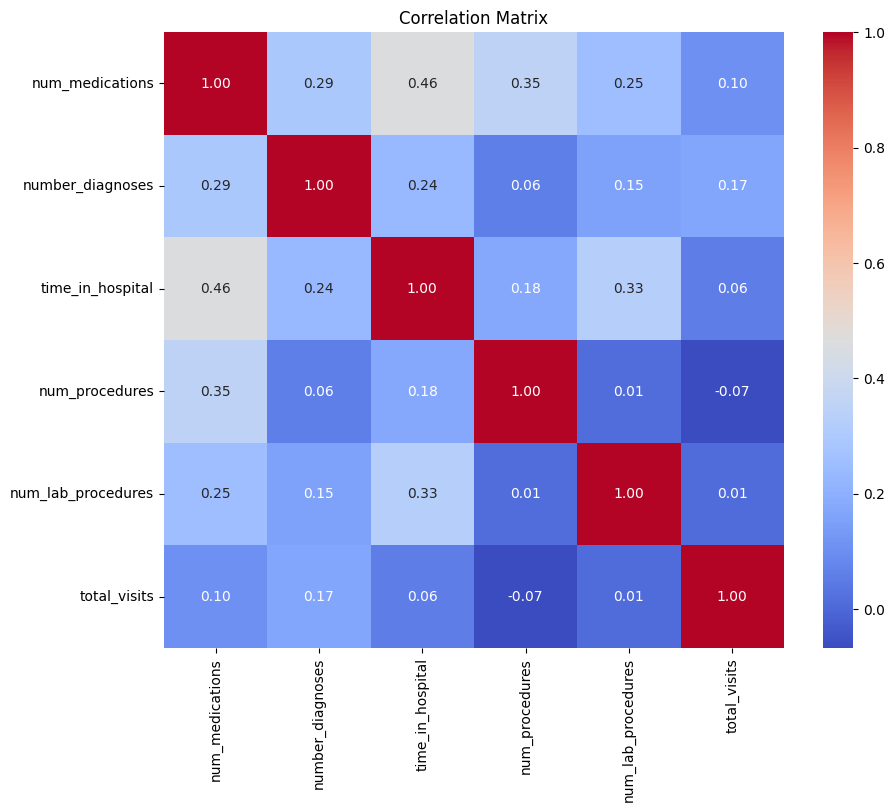

In [ ]:

# Compute the correlation matrix
corr_matrix = df_train[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(df_train[cols].values, i) for i in range(df_train[cols].shape[1])]
vif['Feature'] = cols
vif = vif.sort_values('VIF', ascending=False)

print(vif)


        VIF             Feature
0  1.509440     num_medications
3  1.369807    time_in_hospital
4  1.165649      num_procedures
5  1.150557  num_lab_procedures
2  1.139161    number_diagnoses
1  1.045650        total_visits


orrelation heatmap and vif values -  no Multi-Collinearity in the numerical features.

In [ ]:
# Compute the correlation matrix
corr_matrix = df_num.corr()

# Unstack the correlation matrix to get pairs of features with their correlation values
corr_pairs = corr_matrix.unstack()

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs != 1]

# Sort the correlations in descending order
sorted_corr_pairs = corr_pairs.sort_values(ascending=False)

# Display the most correlated pairs
print("Most correlated feature pairs:")
print(sorted_corr_pairs.head(10))  # Adjust the number to see more pairs if needed


Most correlated feature pairs:
time_in_hospital    num_medications       0.467879
num_medications     time_in_hospital      0.467879
num_procedures      num_medications       0.360976
num_medications     num_procedures        0.360976
num_lab_procedures  time_in_hospital      0.333222
time_in_hospital    num_lab_procedures    0.333222
num_medications     number_diagnoses      0.289994
number_diagnoses    num_medications       0.289994
num_medications     num_lab_procedures    0.260080
num_lab_procedures  num_medications       0.260080
dtype: float64


In [ ]:
# Check the data types of features
print(df_train.dtypes)

gender                       object
age                          object
discharge_disposition_id     object
admission_source_id          object
time_in_hospital            float64
num_lab_procedures          float64
num_procedures              float64
num_medications             float64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses            float64
max_glu_serum                object
A1Cresult                    object
metformin                    object
repaglinide                  object
glimepiride                  object
glipizide                    object
glyburide                    object
pioglitazone                 object
rosiglitazone                object
insulin                      object
diabetesMed                  object
readmitted                    int64
race_Asian                   object
race_Caucasian               object
race_Hispanic                object
race_Other                  

Class Imbalance

SMOTE (Synthetic Minority Over-sampling Technique) is a method used to address class imbalance by generating synthetic samples for the minority class. Here's a step-by-step guide on how to apply SMOTE

In [ ]:
df_train['readmitted'].value_counts()

,count
readmitted,
0,61154
1,7831


In [ ]:
class_counts = df_train['readmitted'].value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Imbalance Ratio (Majority:Minority) = {imbalance_ratio:.2f}:1")

Imbalance Ratio (Majority:Minority) = 7.81:1


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
x = df_train.drop(["readmitted"], axis=1)  # Features
y = df_train["readmitted"]  # Target variable

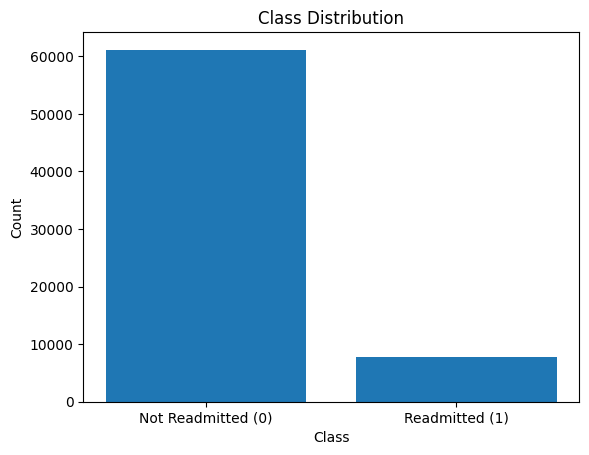

In [ ]:
# Count occurrences of each class
count_class = y.value_counts()


plt.bar(count_class.index, count_class.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(count_class.index, ['Not Readmitted (0)', 'Readmitted (1)'])
plt.show()


In [ ]:
# Initialize SMOTE with the minority sampling strategy
smote = SMOTE(sampling_strategy='minority', random_state=123)

# Apply SMOTE to balance the data
X_resampled, y_resampled = smote.fit_resample(x, y)

# DataFrame from the resampled data
df_train_resampled = pd.DataFrame(X_resampled, columns=x.columns)
df_train_resampled['readmitted'] = y_resampled

# shuffle and reset the index of the new DataFrame
df_train = df_train_resampled.sample(frac=1, random_state=123).reset_index(drop=True)

print("Class distribution after SMOTE:")
print(df_train['readmitted'].value_counts())

Class distribution after SMOTE:
readmitted
1    61154
0    61154
Name: count, dtype: int64


In [ ]:
columns = cols + cat

In [ ]:
columns_with_target = columns + ['readmitted']

df_valid = df_valid[columns_with_target]
df_test = df_test[columns_with_target]


In [ ]:
X_train = df_train[columns].values
y_train = df_train['readmitted'].values

In [ ]:
# Create feature matrices for validation and test datasets
X_valid = df_valid[columns].values
y_valid = df_valid['readmitted'].values



In [ ]:
df_train.to_csv('df_train_final.csv', index=False)
df_valid.to_csv('df_valid_final.csv', index=False)
df_test.to_csv('df_test_final.csv', index=False)

files.download('df_train_final.csv')
files.download('df_valid_final.csv')
files.download('df_test_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_valid.npy', X_valid)
np.save('y_valid.npy', y_valid)



In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)
print("X_test shape:", X_test.shape)

X_train shape: (122308, 33)
y_train shape: (122308,)
X_valid shape: (14894, 33)
y_valid shape: (14894,)
X_test shape: (14896, 33)


In [ ]:
print(df_train.isnull().sum())

gender                      0
age                         0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
glimepiride                 0
glipizide                   0
glyburide                   0
pioglitazone                0
rosiglitazone               0
insulin                     0
diabetesMed                 0
race_Asian                  0
race_Caucasian              0
race_Hispanic               0
race_Other                  0
race_UNK                    0
max_glu_serum_not_taken     0
A1Cresult_not_taken         0
total_visits                0
num_changes                 0
insulin_treatment           0
readmitted

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file
df_train.to_csv('diabetes_train_final.csv', index=False)

# Download the file
files.download('diabetes_train_final.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modeling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_train_final.csv to df_train_final.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_test_final (1).csv to df_test_final (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_valid_final (1).csv to df_valid_final (1).csv


In [ ]:
df_valid = pd.read_csv('df_valid_final (1).csv')

In [ ]:
df_test = pd.read_csv('df_test_final (1).csv')

In [ ]:
df_train = pd.read_csv('df_train_final.csv')

In [ ]:
columns = df_train.columns.tolist()
columns.remove('readmitted')

In [ ]:
X_train = df_train[columns].values
y_train = df_train['readmitted'].values

In [ ]:
X_valid = df_valid[columns].values
y_valid = df_valid['readmitted'].values

In [ ]:
    # Calculates the prevalence of the positive class

def calc_prevalence(y_actual):
  return (sum(y_actual)/len(y_actual))

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report


In [ ]:
def cal_specificity(y_actual, y_pred, thresh):
    # calculates specificity
    return sum((y_pred < thresh) & (y_actual == 0)) /sum(y_actual ==0)

def report(y_actual, y_pred, thresh):

    auc = roc_auc_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precision = precision_score(y_actual, (y_pred > thresh))
    specificity = cal_specificity(y_actual, y_pred, thresh)
    f1 = f1_score(y_actual, (y_pred > thresh))
    conf_matrix = confusion_matrix(y_actual, (y_pred > thresh))
    print('--- Model Performance Metrics ---')
    print('AUC:%.3f'%auc)
    print('Accuracy:%.3f'%accuracy)
    print('Recall:%.3f'%recall)
    print('Precision:%.3f'%precision)
    print('Specificity:%.3f'%specificity)
    print('Prevalence:%.3f'%calc_prevalence(y_actual))
    print('F1 Score: %.3f' % f1)
    print(' ')

    print('--- Confusion Matrix ---')
    print(conf_matrix)
    print(' ')
    return auc, accuracy, recall, precision, specificity, f1, conf_matrix


In [ ]:
thresh = 0.5

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state = 123, max_iter=3000)
lr.fit(X_train, y_train)

print("Number of iterations:", lr.n_iter_)

Number of iterations: [1973]


In [ ]:
y_train_pred = lr.predict_proba(X_train)[:,1]
y_valid_pred = lr.predict_proba(X_valid)[:,1]

print('Logistic Regression')
print('Training')
lr_train_auc, lr_train_accuracy, lr_train_recall, \
    lr_train_precision, lr_train_specificity, lr_train_f1, lr_train_conf_matrix = \
    report(y_train, y_train_pred, thresh)

print('Validation')
lr_valid_auc, lr_valid_accuracy, lr_valid_recall, \
    lr_valid_precision, lr_valid_specificity, lr_valid_f1, lr_valid_conf_matrix = \
    report(y_valid, y_valid_pred, thresh)


Logistic Regression
Training
--- Model Performance Metrics ---
AUC:0.782
Accuracy:0.711
Recall:0.721
Precision:0.706
Specificity:0.700
Prevalence:0.500
F1 Score: 0.713
 
--- Confusion Matrix ---
[[42819 18335]
 [17071 44083]]
 
Validation
--- Model Performance Metrics ---
AUC:0.569
Accuracy:0.274
Recall:0.853
Precision:0.118
Specificity:0.201
Prevalence:0.112
F1 Score: 0.208
 
--- Confusion Matrix ---
[[ 2656 10576]
 [  244  1418]]
 


In [ ]:
feature_names = [
    'num_medications', 'number_diagnoses', 'time_in_hospital',
    'num_procedures', 'num_lab_procedures', 'total_visits', 'gender', 'age',
    'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2',
    'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'insulin', 'diabetesMed', 'race_Asian',
    'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_UNK',
    'max_glu_serum_not_taken', 'A1Cresult_not_taken', 'num_changes',
    'insulin_treatment'
]


In [ ]:
import numpy as np
import pandas as pd

# Step 1: Calculate Coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,  # Use the stored feature names
    'Coefficient': lr.coef_[0]  # Extract coefficients
}).sort_values(by='Coefficient', ascending=False)

# Step 2: Convert Coefficients to Odds Ratios
coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient'])

# Display the results
coefficients



,Feature,Coefficient,Odds Ratio
18,glipizide,0.604802,1.830889
19,glyburide,0.588996,1.802178
16,repaglinide,0.556283,1.744177
5,total_visits,0.409594,1.506206
17,glimepiride,0.408901,1.505162
15,metformin,0.388484,1.474744
20,pioglitazone,0.367163,1.443633
21,rosiglitazone,0.347455,1.415461
0,num_medications,0.097378,1.102277
1,number_diagnoses,0.088888,1.092958


Stochastic gradient descent

In [ ]:
from sklearn.linear_model import SGDClassifier
sgdc=SGDClassifier(loss = 'log_loss',alpha = 0.2,random_state = 123)
sgdc.fit(X_train, y_train)

SGDClassifier(alpha=0.2, loss='log_loss', random_state=123)

In [ ]:
# Predict probabilities
y_train_pred = sgdc.predict_proba(X_train)[:, 1]
y_valid_pred = sgdc.predict_proba(X_valid)[:, 1]

print('Stochastic Gradient Descent')
print('Training:')
sgdc_train_auc, sgdc_train_accuracy, sgdc_train_recall, \
    sgdc_train_precision, sgdc_train_specificity, sgdc_train_f1, sgdc_train_conf_matrix = \
    report(y_train, y_train_pred, thresh)

print('Validation:')
sgdc_valid_auc, sgdc_valid_accuracy, sgdc_valid_recall, \
    sgdc_valid_precision, sgdc_valid_specificity, sgdc_valid_f1, sgdc_valid_conf_matrix = \
    report(y_valid, y_valid_pred, thresh)

Stochastic Gradient Descent
Training:
--- Model Performance Metrics ---
AUC:0.692
Accuracy:0.634
Recall:0.746
Precision:0.610
Specificity:0.522
Prevalence:0.500
F1 Score: 0.671
 
--- Confusion Matrix ---
[[31939 29215]
 [15553 45601]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.585
Accuracy:0.112
Recall:1.000
Precision:0.112
Specificity:0.001
Prevalence:0.112
F1 Score: 0.201
 
--- Confusion Matrix ---
[[   11 13221]
 [    0  1662]]
 


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth = 7, random_state = 123)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=123)

In [ ]:
y_train_pred = tree.predict_proba(X_train)[:,1]
y_valid_pred = tree.predict_proba(X_valid)[:,1]

print('Decision Tree')
print('Training:')
tree_train_auc, tree_train_accuracy, tree_train_recall, \
    tree_train_precision, tree_train_specificity, tree_train_f1, tree_train_conf_matrix = \
    report(y_train, y_train_pred, thresh)

print('Validation:')
tree_valid_auc, tree_valid_accuracy, tree_valid_recall, \
    tree_valid_precision, tree_valid_specificity, tree_valid_f1, tree_valid_conf_matrix = \
    report(y_valid, y_valid_pred, thresh)


Decision Tree
Training:
--- Model Performance Metrics ---
AUC:0.869
Accuracy:0.805
Recall:0.698
Precision:0.888
Specificity:0.912
Prevalence:0.500
F1 Score: 0.781
 
--- Confusion Matrix ---
[[55753  5401]
 [18481 42673]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.417
Accuracy:0.112
Recall:1.000
Precision:0.112
Specificity:0.000
Prevalence:0.112
F1 Score: 0.201
 
--- Confusion Matrix ---
[[    0 13232]
 [    0  1662]]
 


Random Forest

In [ ]:
thresh = 0.5

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(max_depth= 5, random_state = 123)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=123)

In [ ]:
y_train_pred = rf.predict_proba(X_train)[:,1]
y_valid_pred = rf.predict_proba(X_valid)[:,1]

print('Random Forest')
print('Training:')
rf_train_auc, rf_train_accuracy, rf_train_recall, rf_train_precision, rf_train_specificity, rf_train_f1, rf_train_conf_matrix = \
    report(y_train, y_train_pred, thresh)

print('Validation:')
rf_valid_auc, rf_valid_accuracy, rf_valid_recall, rf_valid_precision, rf_valid_specificity, rf_valid_f1, rf_valid_conf_matrix = \
    report(y_valid, y_valid_pred, thresh)


Random Forest
Training:
--- Model Performance Metrics ---
AUC:0.848
Accuracy:0.755
Recall:0.763
Precision:0.751
Specificity:0.746
Prevalence:0.500
F1 Score: 0.757
 
--- Confusion Matrix ---
[[45650 15504]
 [14495 46659]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.457
Accuracy:0.163
Recall:0.925
Precision:0.111
Specificity:0.067
Prevalence:0.112
F1 Score: 0.198
 
--- Confusion Matrix ---
[[  885 12347]
 [  124  1538]]
 


Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth= 5, random_state=123)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=5, random_state=123)

In [ ]:
y_train_pred = gbc.predict_proba(X_train)[:,1]
y_valid_pred = gbc.predict_proba(X_valid)[:,1]

print('Gradient Boosting Classifier')
print('Training:')
gbc_train_auc, gbc_train_accuracy, gbc_train_recall, gbc_train_precision, gbc_train_specificity, gbc_train_f1, gbc_train_conf_matrix = report(y_train, y_train_pred, thresh)

print('Validation:')
gbc_valid_auc, gbc_valid_accuracy, gbc_valid_recall, gbc_valid_precision, gbc_valid_specificity, gbc_valid_f1, gbc_valid_conf_matrix = report(y_valid, y_valid_pred, thresh)


Gradient Boosting Classifier
Training:
--- Model Performance Metrics ---
AUC:0.974
Accuracy:0.944
Recall:0.894
Precision:0.993
Specificity:0.994
Prevalence:0.500
F1 Score: 0.941
 
--- Confusion Matrix ---
[[60775   379]
 [ 6494 54660]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.498
Accuracy:0.396
Recall:0.629
Precision:0.111
Specificity:0.367
Prevalence:0.112
F1 Score: 0.189
 
--- Confusion Matrix ---
[[4851 8381]
 [ 616 1046]]
 


XGBClassifier

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=123)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=123, ...)

In [ ]:
y_train_pred = xgb_model.predict_proba(X_train)[:, 1]
y_valid_pred = xgb_model.predict_proba(X_valid)[:, 1]

thresh = 0.5

print('XGBoost Classifier')
print('Training:')
xgb_train_auc, xgb_train_accuracy, xgb_train_recall, xgb_train_precision, xgb_train_specificity, xgb_train_f1, xgb_train_conf_matrix = report(y_train, y_train_pred, thresh)

print('Validation:')
xgb_valid_auc, xgb_valid_accuracy, xgb_valid_recall, xgb_valid_precision, xgb_valid_specificity, xgb_valid_f1, xgb_valid_conf_matrix = report(y_valid, y_valid_pred, thresh)

XGBoost Classifier
Training:
--- Model Performance Metrics ---
AUC:0.945
Accuracy:0.908
Recall:0.829
Precision:0.984
Specificity:0.987
Prevalence:0.500
F1 Score: 0.900
 
--- Confusion Matrix ---
[[60338   816]
 [10459 50695]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.438
Accuracy:0.158
Recall:0.896
Precision:0.108
Specificity:0.066
Prevalence:0.112
F1 Score: 0.192
 
--- Confusion Matrix ---
[[  870 12362]
 [  173  1489]]
 


Analyze results of the baseline models

In [ ]:
df_results = pd.DataFrame({
    'classifier': ['LG', 'LG', 'SGD', 'SGD', 'DT', 'DT',
                   'RF', 'RF', 'GB', 'GB', 'XGB', 'XGB'],
    'data_set': ['train', 'valid'] * 6,
    'auc': [lr_train_auc, lr_valid_auc, sgdc_train_auc, sgdc_valid_auc, tree_train_auc, tree_valid_auc,
            rf_train_auc, rf_valid_auc, gbc_train_auc, gbc_valid_auc, xgb_train_auc, xgb_valid_auc],
    'accuracy': [lr_train_accuracy, lr_valid_accuracy, sgdc_train_accuracy, sgdc_valid_accuracy, tree_train_accuracy, tree_valid_accuracy,
                 rf_train_accuracy, rf_valid_accuracy, gbc_train_accuracy, gbc_valid_accuracy, xgb_train_accuracy, xgb_valid_accuracy],
    'recall': [lr_train_recall, lr_valid_recall, sgdc_train_recall, sgdc_valid_recall, tree_train_recall, tree_valid_recall,
               rf_train_recall, rf_valid_recall, gbc_train_recall, gbc_valid_recall, xgb_train_recall, xgb_valid_recall],
    'precision': [lr_train_precision, lr_valid_precision, sgdc_train_precision, sgdc_valid_precision, tree_train_precision, tree_valid_precision,
                  rf_train_precision, rf_valid_precision, gbc_train_precision, gbc_valid_precision, xgb_train_precision, xgb_valid_precision],
    'specificity': [lr_train_specificity, lr_valid_specificity, sgdc_train_specificity, sgdc_valid_specificity, tree_train_specificity, tree_valid_specificity,
                    rf_train_specificity, rf_valid_specificity, gbc_train_specificity, gbc_valid_specificity, xgb_train_specificity, xgb_valid_specificity],
    'f1_score': [lr_train_f1, lr_valid_f1, sgdc_train_f1, sgdc_valid_f1, tree_train_f1, tree_valid_f1,
                 rf_train_f1, rf_valid_f1, gbc_train_f1, gbc_valid_f1, xgb_train_f1, xgb_valid_f1]
})

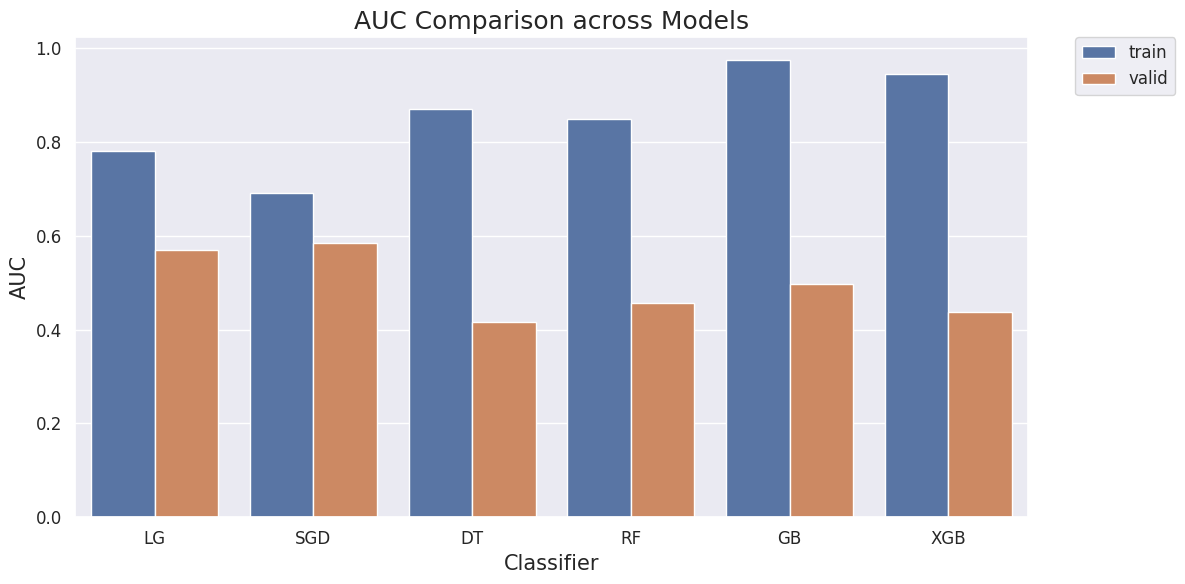

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="darkgrid")

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="classifier", y="auc", hue="data_set", data=df_results)
ax.set_xlabel('Classifier', fontsize=15)
ax.set_ylabel('AUC', fontsize=15)
ax.tick_params(labelsize=12)
plt.title('AUC Comparison across Models', fontsize=18)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=12)
plt.tight_layout()
plt.show()

Feature Importance

In [ ]:
feature_names = ['num_medications', 'number_diagnoses', 'time_in_hospital',
                  'num_procedures', 'num_lab_procedures', 'total_visits', 'gender', 'age',
                  'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2',
                  'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
                  'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
                  'rosiglitazone', 'insulin', 'diabetesMed', 'race_Asian',
                  'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_UNK',
                  'max_glu_serum_not_taken', 'A1Cresult_not_taken', 'num_changes',
                  'insulin_treatment']

In [ ]:
feature_importances = pd.DataFrame(lr.coef_[0],
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance',
                                                                        ascending=False)

In [ ]:
feature_importances.head()

,importance
glipizide,0.604802
glyburide,0.588996
repaglinide,0.556283
total_visits,0.409594
glimepiride,0.408901


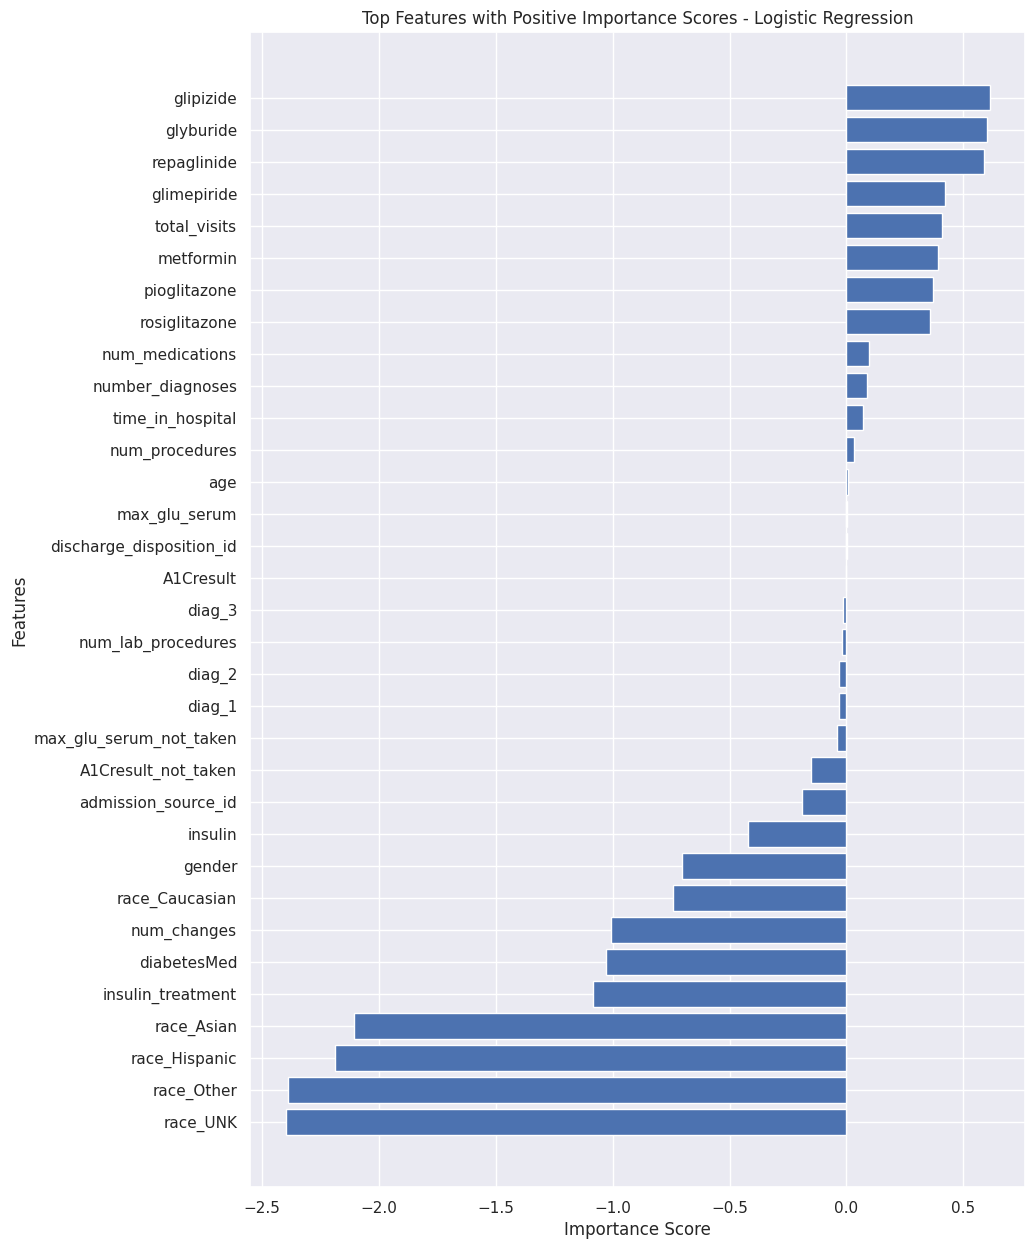

In [ ]:
num = min(50, len(feature_importances))

# Plot the top positive features
ylocs = np.arange(num)
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(figsize=(10, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Features with Positive Importance Scores - Logistic Regression')
plt.yticks(ylocs, feature_labels)
plt.show()

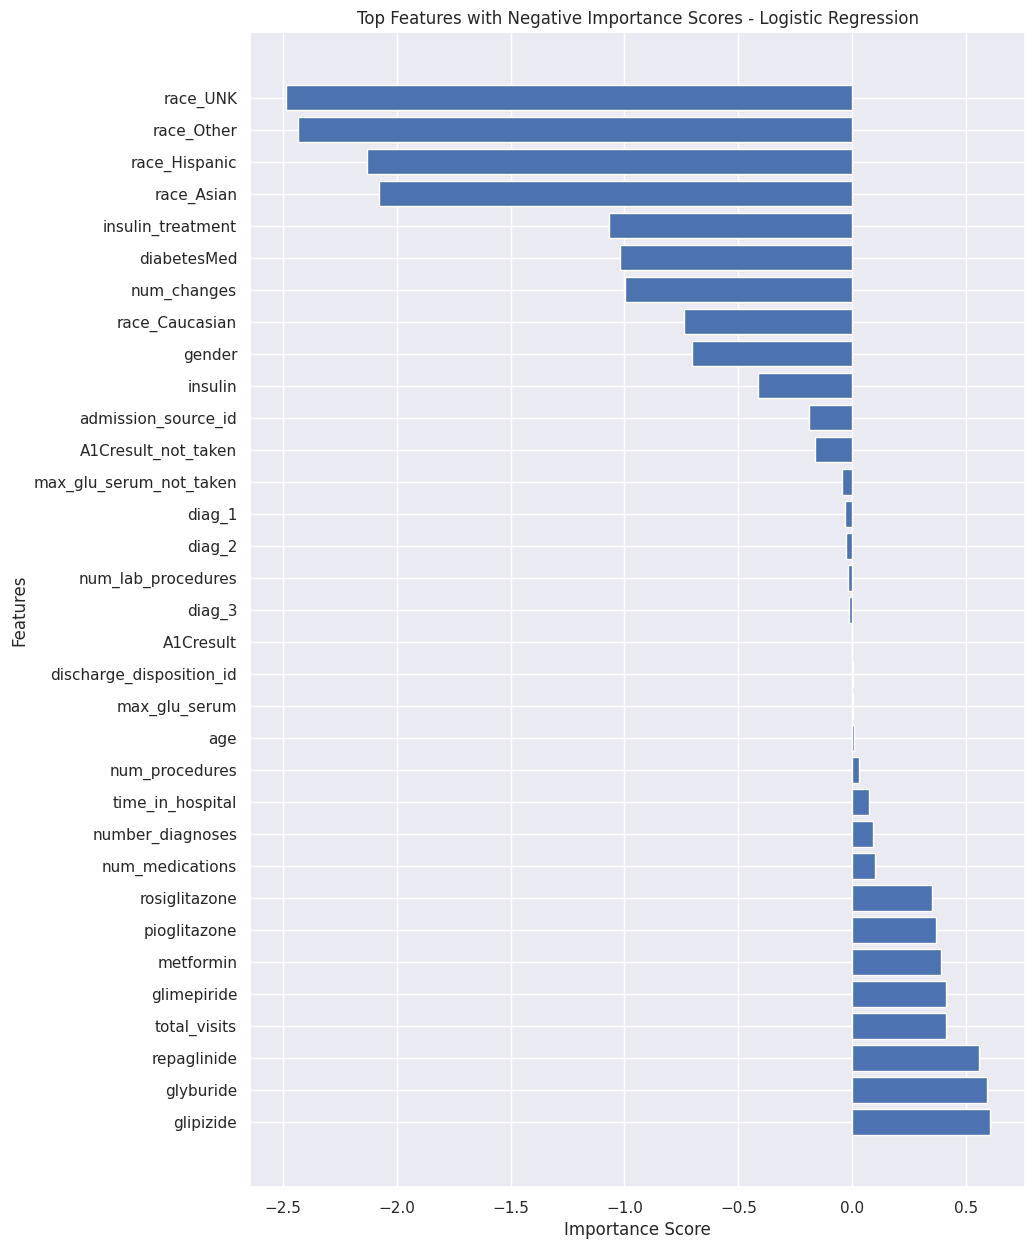

In [ ]:
values_to_plot = feature_importances.iloc[-num:].values.ravel()
feature_labels = list(feature_importances.iloc[-num:].index)

plt.figure(figsize=(10, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Features with Negative Importance Scores - Logistic Regression')
plt.yticks(ylocs, feature_labels)
plt.show()

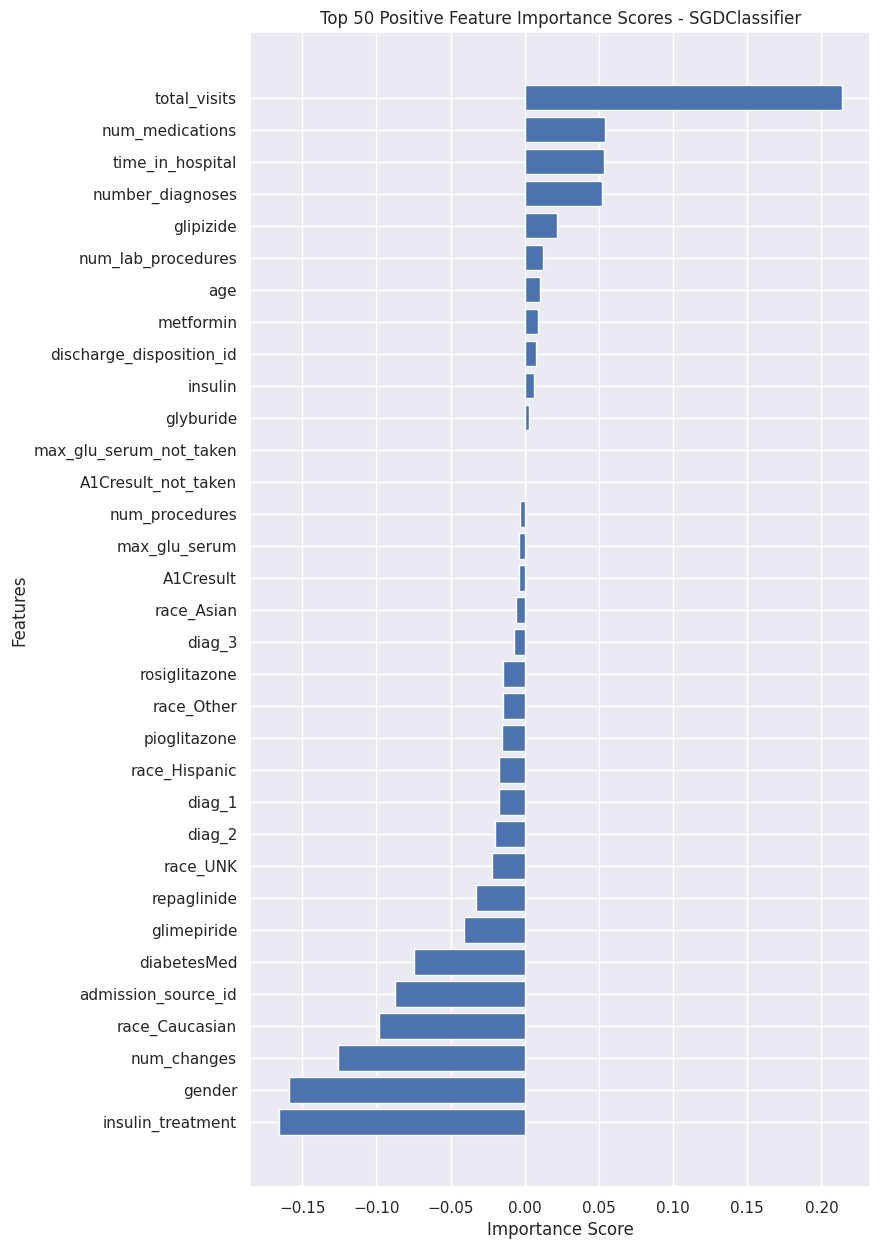

In [ ]:
feature_importances = pd.DataFrame(sgdc.coef_[0],
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance', ascending=False)

num = min(50, len(feature_importances))

# Plot the top positive features
ylocs = np.arange(num)
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Positive Feature Importance Scores - SGDClassifier')
plt.yticks(ylocs, feature_labels)
plt.show()


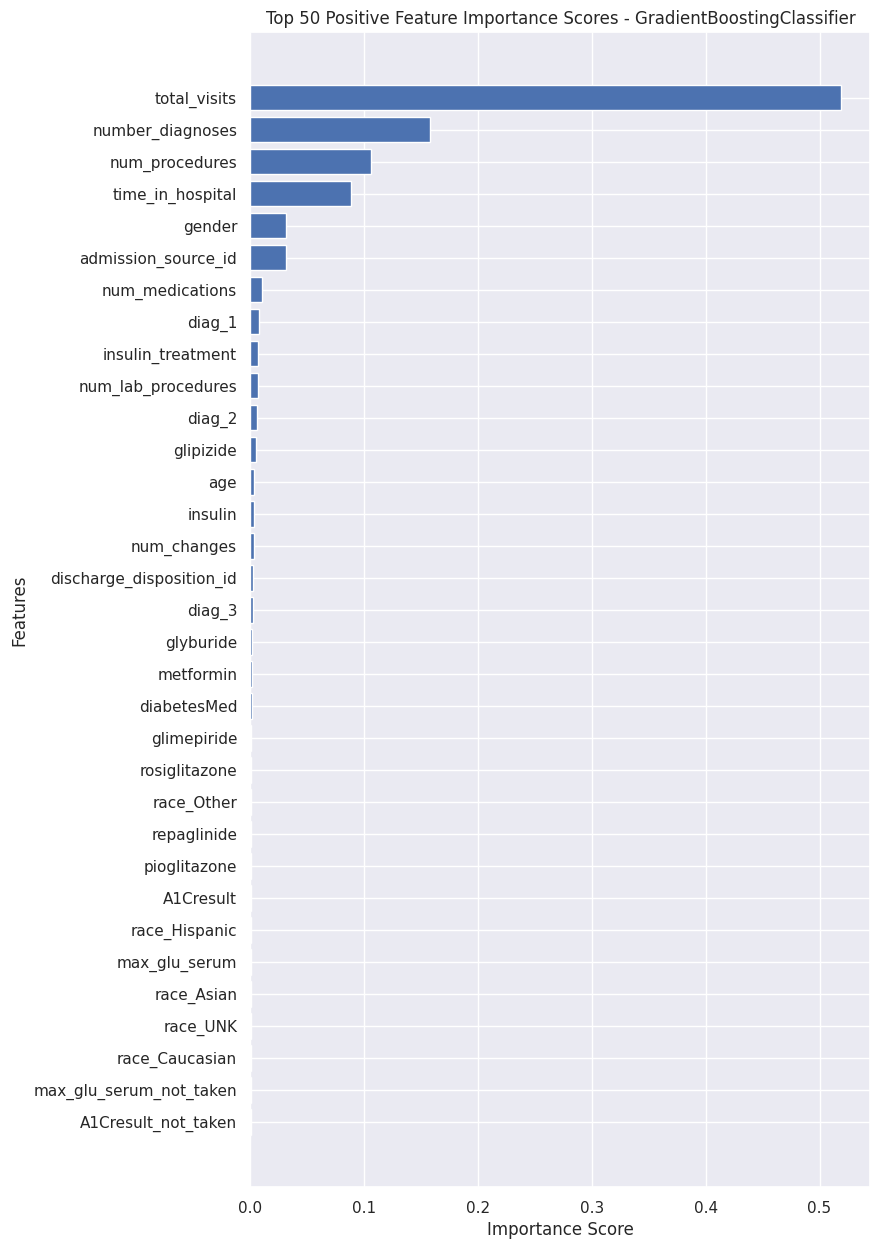

In [ ]:
feature_importances = pd.DataFrame(gbc.feature_importances_,
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance', ascending=False)

num = min(50, len(feature_importances))

# Plot the top positive features
ylocs = np.arange(num)
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Positive Feature Importance Scores - GradientBoostingClassifier')
plt.yticks(ylocs, feature_labels)
plt.show()



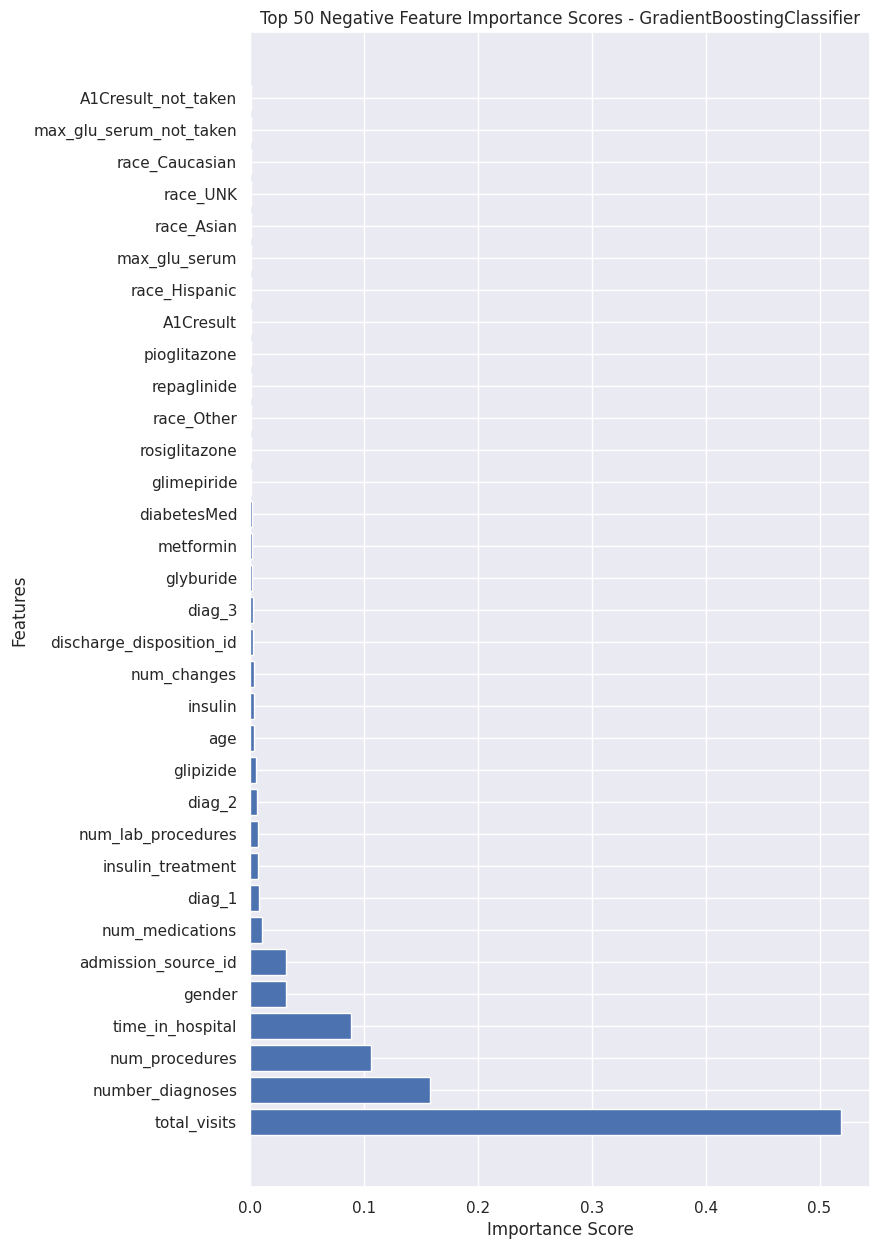

In [ ]:
values_to_plot = feature_importances.iloc[-num:].values.ravel()
feature_labels = list(feature_importances.iloc[-num:].index)

plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Negative Feature Importance Scores - GradientBoostingClassifier')
plt.yticks(ylocs, feature_labels)
plt.show()

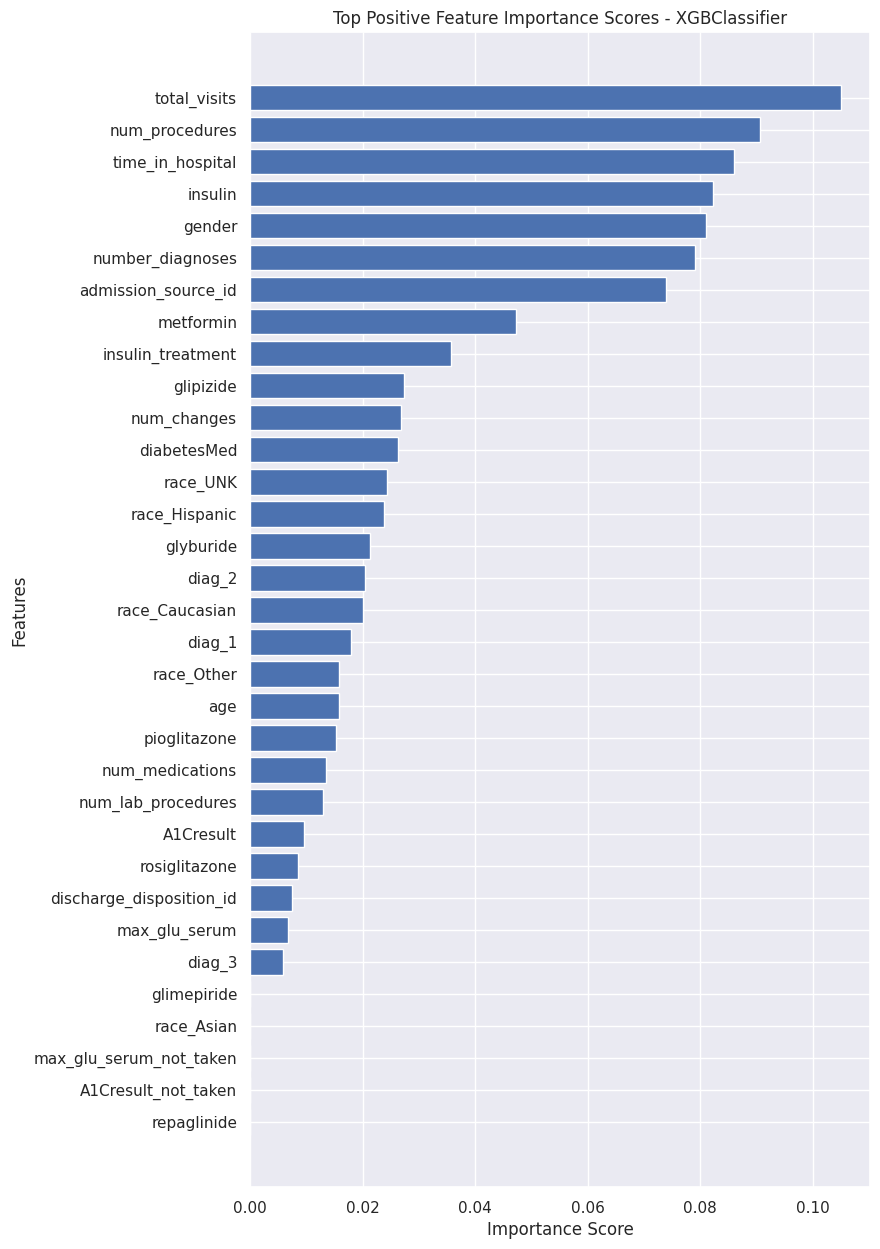

In [ ]:
# Create a DataFrame for feature importances
feature_importances = pd.DataFrame(xgb_model.feature_importances_,
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance', ascending=False)



num = min(50, len(feature_importances))

# Plot the top positive features
ylocs = np.arange(num)
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Positive Feature Importance Scores - XGBClassifier')
plt.yticks(ylocs, feature_labels)
plt.show()


In [ ]:
feature_importances.head(15)

,importance
total_visits,0.105037
num_procedures,0.090686
time_in_hospital,0.086074
insulin,0.082296
gender,0.081130
number_diagnoses,0.079017
admission_source_id,0.073979
metformin,0.047261
insulin_treatment,0.035633
glipizide,0.027252


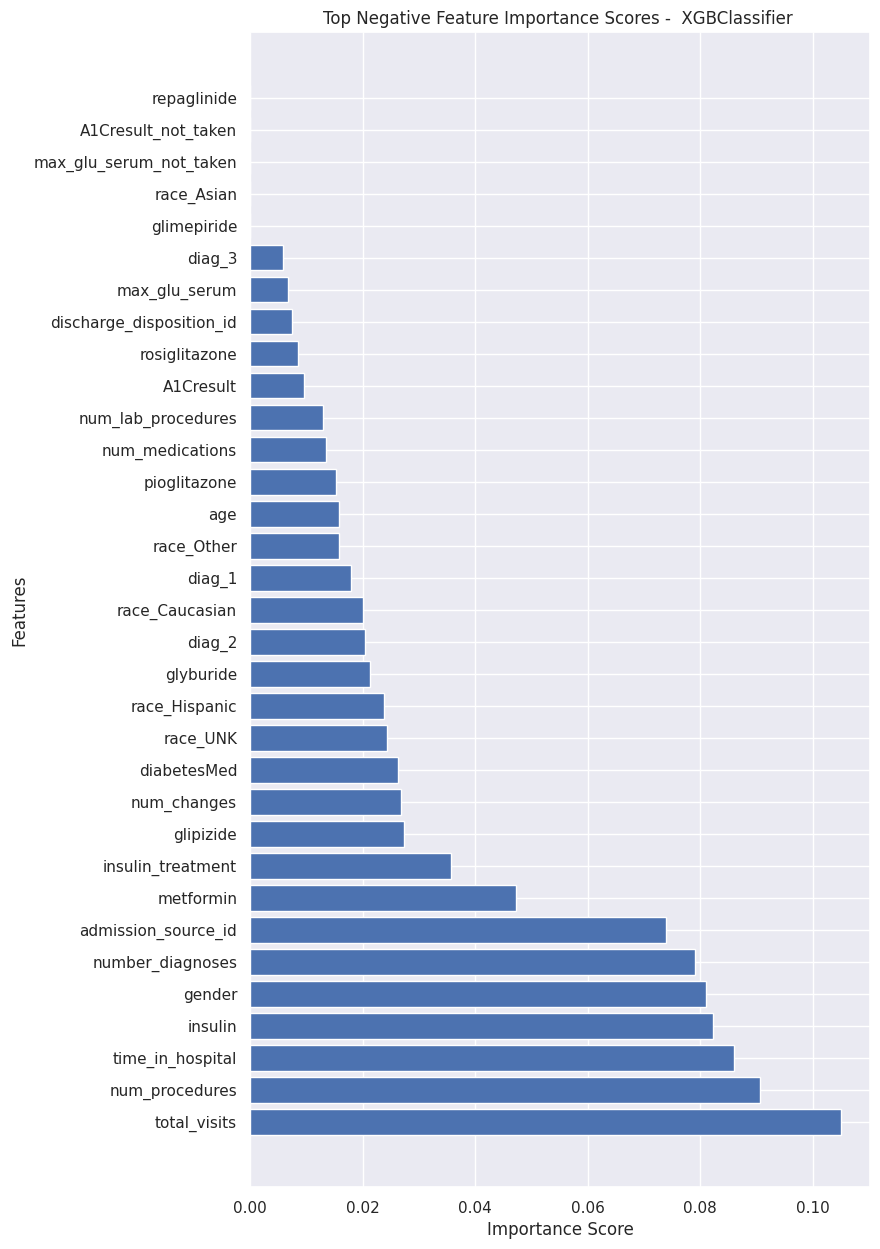

In [ ]:
values_to_plot = feature_importances.iloc[-num:].values.ravel()
feature_labels = list(feature_importances.iloc[-num:].index)

plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Negative Feature Importance Scores -  XGBClassifier ')
plt.yticks(ylocs, feature_labels)
plt.show()

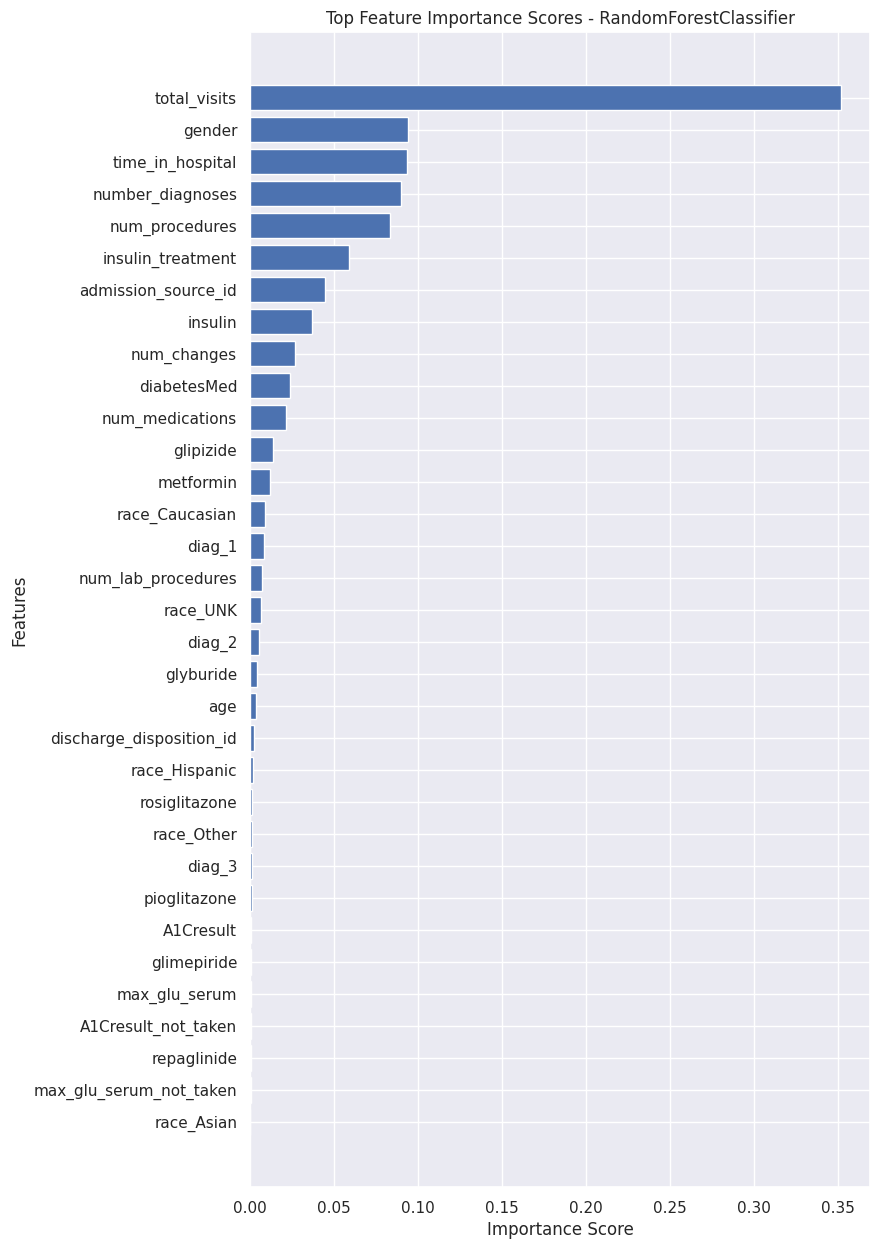

In [ ]:
feature_importances = pd.DataFrame(rf.feature_importances_,
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance', ascending=False)
num = min(50, len(feature_importances))

# Plot the top positive features
ylocs = np.arange(num)
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]


plt.figure(figsize=(8, 15))
plt.barh(ylocs, values_to_plot, align='center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Top Feature Importance Scores - RandomForestClassifier')
plt.yticks(ylocs, feature_labels)
plt.show()

Model Selection: Hyperparameter tuning

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

In [ ]:
xgb_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 100,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 123,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:

param_grid = {
    'n_estimators': [100,500,100],
    'max_depth': [1, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.5, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.7, 0.8],
    'gamma': [0, 0.1, 0.3, 0.5],
    'alpha': [0.01, 0.1, 1],
    'lambda': [0.01, 0.1, 1],
}


from sklearn.metrics import make_scorer, roc_auc_score
auc_scoring = make_scorer(roc_auc_score)

xgb_random = RandomizedSearchCV(estimator = xgb_model, param_distributions = param_grid,
                               n_iter = 30, cv = 5, scoring=auc_scoring,
                               verbose = 1,random_state = 123 ,n_jobs=-1,  error_score='raise')




In [ ]:
t1 = time.time()
xgb_random.fit(X_train, y_train)
t2 = time.time()
print(t2-t1)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


478.2804775238037


In [ ]:
xgb_random.best_params_

{'subsample': 0.5,
 'n_estimators': 500,
 'max_depth': 5,
 'learning_rate': 0.1,
 'lambda': 0.01,
 'gamma': 0.5,
 'colsample_bytree': 0.8,
 'alpha': 0.1}

In [ ]:
y_train_pred = xgb_model.predict_proba(X_train)[:,1]
y_valid_pred = xgb_model.predict_proba(X_valid)[:,1]

print('Baseline XGB')
xgb_train_auc_base = roc_auc_score(y_train, y_train_pred)
xgb_valid_auc_base = roc_auc_score(y_valid, y_valid_pred)

print('Training AUC:%.3f'%(xgb_train_auc_base))
print('Validation AUC:%.3f'%(xgb_valid_auc_base))

print('Optimized XGB')
y_train_pred_random = xgb_random.best_estimator_.predict_proba(X_train)[:,1]
y_valid_pred_random = xgb_random.best_estimator_.predict_proba(X_valid)[:,1]
xgb_train_auc = roc_auc_score(y_train, y_train_pred_random)
xgb_valid_auc = roc_auc_score(y_valid, y_valid_pred_random)

print('Training AUC:%.3f'%(xgb_train_auc))
print('Validation AUC:%.3f'%(xgb_valid_auc))

Baseline XGB
Training AUC:0.945
Validation AUC:0.438
Optimized XGB
Training AUC:0.973
Validation AUC:0.473


In [ ]:
from sklearn.metrics import make_scorer, roc_auc_score

In [ ]:
param_grid_sgdc = {
   'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': [0.0001, 0.001],
    'max_iter': [500, 1000, 2000],
    'penalty': ['l1', 'elasticnet'],
   'alpha': [0.1, 0.3, 0.5, 1.0]

}

from sklearn.metrics import make_scorer, roc_auc_score
auc_scoring = make_scorer(roc_auc_score)

sgdc_random = RandomizedSearchCV(estimator = sgdc, param_distributions = param_grid_sgdc,
                                 n_iter = 20, cv = 5, scoring=auc_scoring,verbose = 0,
                                 random_state = 123 ,n_jobs=-1,  error_score='raise')

t1 = time.time()
sgdc_random.fit(X_train, y_train)
t2 = time.time()
print(t2-t1)

60.42461538314819


In [ ]:
best_params = sgdc_random.best_params_
print("Best Parameters:", best_params)


Best Parameters: {'penalty': 'elasticnet', 'max_iter': 2000, 'learning_rate': 'optimal', 'eta0': 0.001, 'alpha': 0.1}


In [ ]:
best_model = sgdc_random.best_estimator_


In [ ]:
y_train_pred = sgdc.predict_proba(X_train)[:,1]
y_valid_pred = sgdc.predict_proba(X_valid)[:,1]

print('Baseline SGDC')
sgdc_train_auc_base = roc_auc_score(y_train, y_train_pred)
sgdc_valid_auc_base = roc_auc_score(y_valid, y_valid_pred)

print('Training AUC:%.3f'%(sgdc_train_auc_base))
print('Validation AUC:%.3f'%(sgdc_valid_auc_base))


print('Optimized SGDC')
y_train_pred_random = best_model.predict_proba(X_train)[:, 1]
y_valid_pred_random = best_model.predict_proba(X_valid)[:, 1]
sgdc_train_auc = roc_auc_score(y_train, y_train_pred_random)
sgdc_valid_auc = roc_auc_score(y_valid, y_valid_pred_random)

print('Training AUC:%.3f'%(sgdc_train_auc))
print('Validation AUC:%.3f'%(sgdc_valid_auc))


Baseline SGDC
Training AUC:0.692
Validation AUC:0.585
Optimized SGDC
Training AUC:0.685
Validation AUC:0.609


In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
param_grid_gbc = {
'learning_rate': [0.001, 0.01, 0.05],
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 5],
    'min_samples_split': [20, 30],
    'min_samples_leaf': [10, 20],
    'subsample': [0.5, 0.6, 0.7],
    'max_features': [0.4, 0.5, 0.6],
      'min_impurity_decrease': [0.0001, 0.001, 0.01],
    'max_leaf_nodes': [10, 20, 30],

}
from sklearn.metrics import make_scorer, roc_auc_score
auc_scoring = make_scorer(roc_auc_score)

stratified_kfold = StratifiedKFold(n_splits= 4, shuffle=True, random_state=123)

gbc_random = RandomizedSearchCV(estimator = gbc, param_distributions = param_grid_gbc,
                               n_iter = 20, cv=stratified_kfold, scoring=auc_scoring,
                               verbose = 1,random_state = 123 ,n_jobs=-1,  error_score='raise')


In [ ]:
t1 = time.time()
gbc_random.fit(X_train, y_train)
t2 = time.time()
print(t2-t1)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
1722.538899898529


In [ ]:
gbc_random.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_samples_split': 20,
 'min_samples_leaf': 20,
 'min_impurity_decrease': 0.01,
 'max_leaf_nodes': 30,
 'max_features': 0.6,
 'max_depth': 3,
 'learning_rate': 0.05}

In [ ]:
y_train_pred = gbc.predict_proba(X_train)[:,1]
y_valid_pred = gbc.predict_proba(X_valid)[:,1]

print('Baseline GBC')
gbc_train_auc_base = roc_auc_score(y_train, y_train_pred)
gbc_valid_auc_base = roc_auc_score(y_valid, y_valid_pred)

print('Training AUC:%.3f'%(gbc_train_auc_base))
print('Validation AUC:%.3f'%(gbc_valid_auc_base))

print('Optimized GBC')
y_train_pred_random = gbc_random.best_estimator_.predict_proba(X_train)[:,1]
y_valid_pred_random = gbc_random.best_estimator_.predict_proba(X_valid)[:,1]
gbc_train_auc = roc_auc_score(y_train, y_train_pred_random)
gbc_valid_auc = roc_auc_score(y_valid, y_valid_pred_random)

print('Training AUC:%.3f'%(gbc_train_auc))
print('Validation AUC:%.3f'%(gbc_valid_auc))

Baseline GBC
Training AUC:0.974
Validation AUC:0.498
Optimized GBC
Training AUC:0.945
Validation AUC:0.444


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

param_grid_gbc = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
    'max_features': [0.6, 0.8]
}


In [ ]:
df_models = pd.DataFrame({'classifier':['SGD','SGD','XGB','XGB','GB','GB'],
                           'data_set':['base','optimized']*3,
                          'auc':[sgdc_valid_auc_base,sgdc_valid_auc,
                                 xgb_valid_auc_base, xgb_valid_auc,
                                 gbc_valid_auc_base,gbc_valid_auc,],
                          })


In [ ]:
df_models

,classifier,data_set,auc
0,SGD,base,0.585173
1,SGD,optimized,0.608595
2,XGB,base,0.438453
3,XGB,optimized,0.472825
4,GB,base,0.498022
5,GB,optimized,0.444159


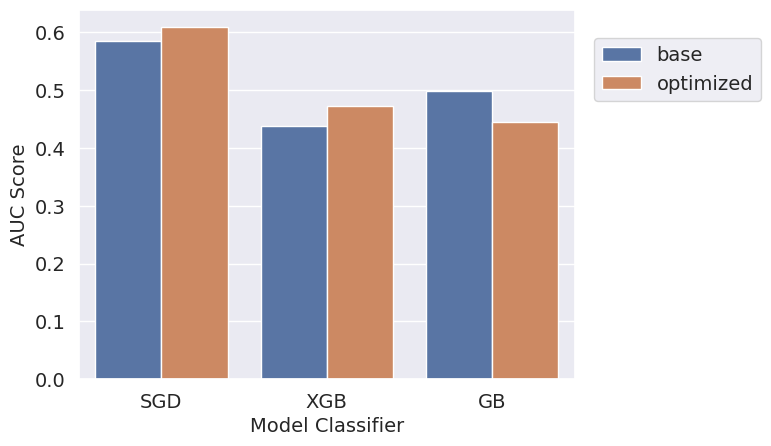

In [ ]:

ax = sns.barplot(x="classifier", y="auc", hue="data_set", data=df_models)
ax.set_xlabel('Model Classifier', fontsize=14)
ax.set_ylabel('AUC Score', fontsize=14)
ax.tick_params(labelsize=14)

plt.legend(bbox_to_anchor=(1.02, 0.95), loc='upper left', borderaxespad=0.5, fontsize=14)


In [ ]:
import pickle

In [ ]:
pickle.dump(sgdc_random.best_estimator_, open('best_classifier.pkl', 'wb'),protocol = 4)

In [ ]:
X_test = df_test[columns].values
y_test = df_test['readmitted'].values

In [ ]:
best_model = pickle.load(open('best_classifier.pkl','rb'))

In [ ]:
y_train_pred = best_model.predict_proba(X_train)[:,1]
y_valid_pred = best_model.predict_proba(X_valid)[:,1]
y_test_pred = best_model.predict_proba(X_test)[:,1]

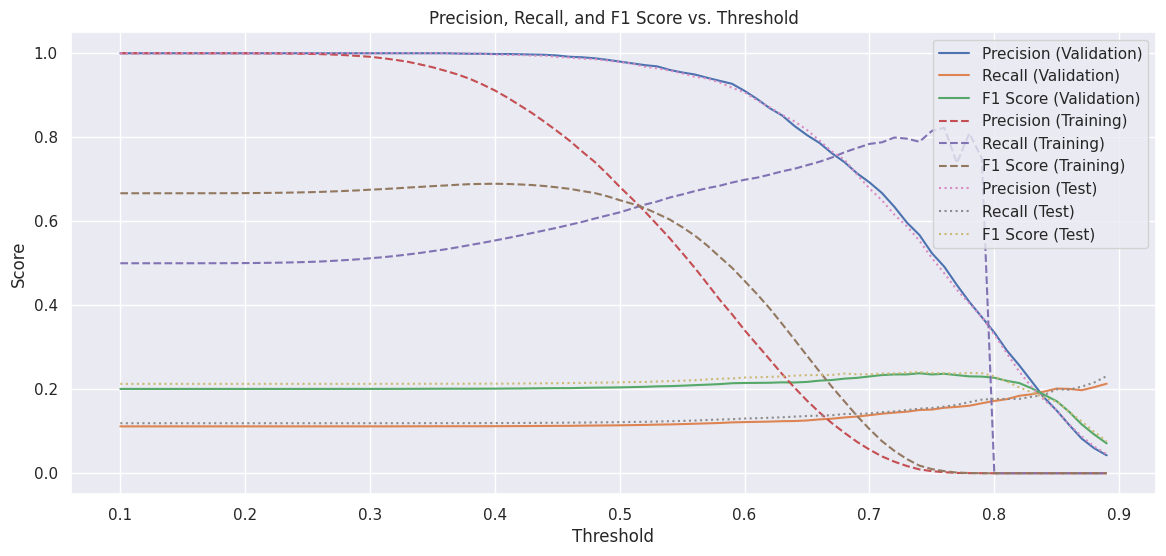

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.01)

# Initialize lists to store results
train_results = []
valid_results = []
test_results = []

for thresh in thresholds:
    # Apply threshold to predictions
    y_train_pred_thresh = (y_train_pred > thresh).astype(int)
    y_valid_pred_thresh = (y_valid_pred > thresh).astype(int)
    y_test_pred_thresh = (y_test_pred > thresh).astype(int)

    # Calculate metrics for training data
    train_recall = recall_score(y_train, y_train_pred_thresh)
    train_precision = precision_score(y_train, y_train_pred_thresh, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred_thresh)

    # Calculate metrics for validation data
    valid_recall = recall_score(y_valid, y_valid_pred_thresh)
    valid_precision = precision_score(y_valid, y_valid_pred_thresh, zero_division=0)
    valid_f1 = f1_score(y_valid, y_valid_pred_thresh)

    # Calculate metrics for test data
    test_recall = recall_score(y_test, y_test_pred_thresh)
    test_precision = precision_score(y_test, y_test_pred_thresh, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred_thresh)

    # Store results
    train_results.append((thresh, train_recall, train_precision, train_f1))
    valid_results.append((thresh, valid_recall, valid_precision, valid_f1))
    test_results.append((thresh, test_recall, test_precision, test_f1))

# Convert to NumPy arrays for easier plotting
train_results = np.array(train_results)
valid_results = np.array(valid_results)
test_results = np.array(test_results)

# Plot Precision-Recall and F1 Score against thresholds
plt.figure(figsize=(14, 6))

# Plot for validation set
plt.plot(thresholds, valid_results[:, 1], label="Precision (Validation)")
plt.plot(thresholds, valid_results[:, 2], label="Recall (Validation)")
plt.plot(thresholds, valid_results[:, 3], label="F1 Score (Validation)")

# Optionally, plot for train and test sets
plt.plot(thresholds, train_results[:, 1], label="Precision (Training)", linestyle='--')
plt.plot(thresholds, train_results[:, 2], label="Recall (Training)", linestyle='--')
plt.plot(thresholds, train_results[:, 3], label="F1 Score (Training)", linestyle='--')

plt.plot(thresholds, test_results[:, 1], label="Precision (Test)", linestyle=':')
plt.plot(thresholds, test_results[:, 2], label="Recall (Test)", linestyle=':')
plt.plot(thresholds, test_results[:, 3], label="F1 Score (Test)", linestyle=':')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

Evaluating sgdc on the testing set also

In [ ]:
thresh = 0.7

print('Training:')
train_auc, train_accuracy, train_recall, train_precision, train_specificity, train_f1, train_conf_matrix = report(y_train,y_train_pred, thresh)
print('Validation:')
valid_auc, valid_accuracy, valid_recall, valid_precision, valid_specificity, valid_f1, valid_conf_matrix = report(y_valid,y_valid_pred, thresh)
print('Test:')
test_auc, test_accuracy, test_recall, test_precision, test_specificity, test_f1, test_conf_matrix = report(y_test,y_test_pred, thresh)

Training:
--- Model Performance Metrics ---
AUC:0.685
Accuracy:0.520
Recall:0.056
Precision:0.784
Specificity:0.984
Prevalence:0.500
F1 Score: 0.105
 
--- Confusion Matrix ---
[[60205   949]
 [57707  3447]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.609
Accuracy:0.484
Recall:0.693
Precision:0.138
Specificity:0.458
Prevalence:0.112
F1 Score: 0.230
 
--- Confusion Matrix ---
[[6056 7176]
 [ 511 1151]]
 
Test:
--- Model Performance Metrics ---
AUC:0.600
Accuracy:0.475
Recall:0.678
Precision:0.142
Specificity:0.448
Prevalence:0.119
F1 Score: 0.235
 
--- Confusion Matrix ---
[[5880 7242]
 [ 571 1203]]
 


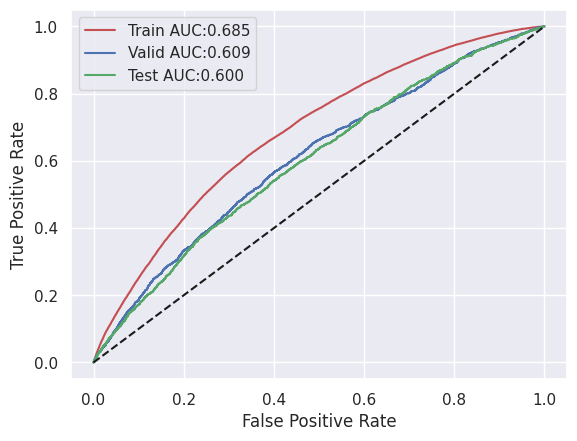

In [ ]:
from sklearn.metrics import roc_curve

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred)
auc_train = roc_auc_score(y_train, y_train_pred)

fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, y_valid_pred)
auc_valid = roc_auc_score(y_valid, y_valid_pred)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

plt.plot(fpr_train, tpr_train, 'r-',label ='Train AUC:%.3f'%auc_train)
plt.plot(fpr_valid, tpr_valid, 'b-',label ='Valid AUC:%.3f'%auc_valid)
plt.plot(fpr_test, tpr_test, 'g-',label ='Test AUC:%.3f'%auc_test)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Evaluation below is not included in the **thesis**

In [ ]:
pickle.dump(xgb_random.best_estimator_, open('second_best_classifier.pkl', 'wb'),protocol = 4)

NameError: name 'pickle' is not defined

In [ ]:
second_best_model = pickle.load(open('second_best_classifier.pkl','rb'))

In [ ]:
y_train_pred = second_best_model.predict_proba(X_train)[:,1]
y_valid_pred = second_best_model.predict_proba(X_valid)[:,1]
y_test_pred = second_best_model.predict_proba(X_test)[:,1]

In [ ]:
thresh = 0.6

print('Training:')
train_auc, train_accuracy, train_recall, train_precision, train_specificity, train_f1, train_conf_matrix = report(y_train,y_train_pred, thresh)
print('Validation:')
valid_auc, valid_accuracy, valid_recall, valid_precision, valid_specificity, valid_f1, valid_conf_matrix = report(y_valid,y_valid_pred, thresh)
print('Test:')
test_auc, test_accuracy, test_recall, test_precision, test_specificity, test_f1, test_conf_matrix = report(y_test,y_test_pred, thresh)

Training:
--- Model Performance Metrics ---
AUC:0.973
Accuracy:0.934
Recall:0.868
Precision:1.000
Specificity:1.000
Prevalence:0.500
F1 Score: 0.929
 
--- Confusion Matrix ---
[[61146     8]
 [ 8048 53106]]
 
Validation:
--- Model Performance Metrics ---
AUC:0.473
Accuracy:0.156
Recall:0.906
Precision:0.108
Specificity:0.062
Prevalence:0.112
F1 Score: 0.193
 
--- Confusion Matrix ---
[[  817 12415]
 [  156  1506]]
 
Test:
--- Model Performance Metrics ---
AUC:0.469
Accuracy:0.164
Recall:0.887
Precision:0.114
Specificity:0.066
Prevalence:0.119
F1 Score: 0.202
 
--- Confusion Matrix ---
[[  868 12254]
 [  200  1574]]
 


In [ ]:
import joblib

# Save the best estimator
joblib.dump(sgdc_random.best_estimator_, 'best_classifier.pkl')


['best_classifier.pkl']

In [ ]:
from google.colab import files

# Download the file to your local machine
files.download('best_classifier.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>